c:\Users\Admin\anaconda3\envs\CIoU\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading DINOv2...


Loading weights: 100%|██████████| 223/223 [00:00<00:00, 4302.92it/s]



Building reference features...
Using 6 reference patches

Extracting patch features...

Computing similarity map...


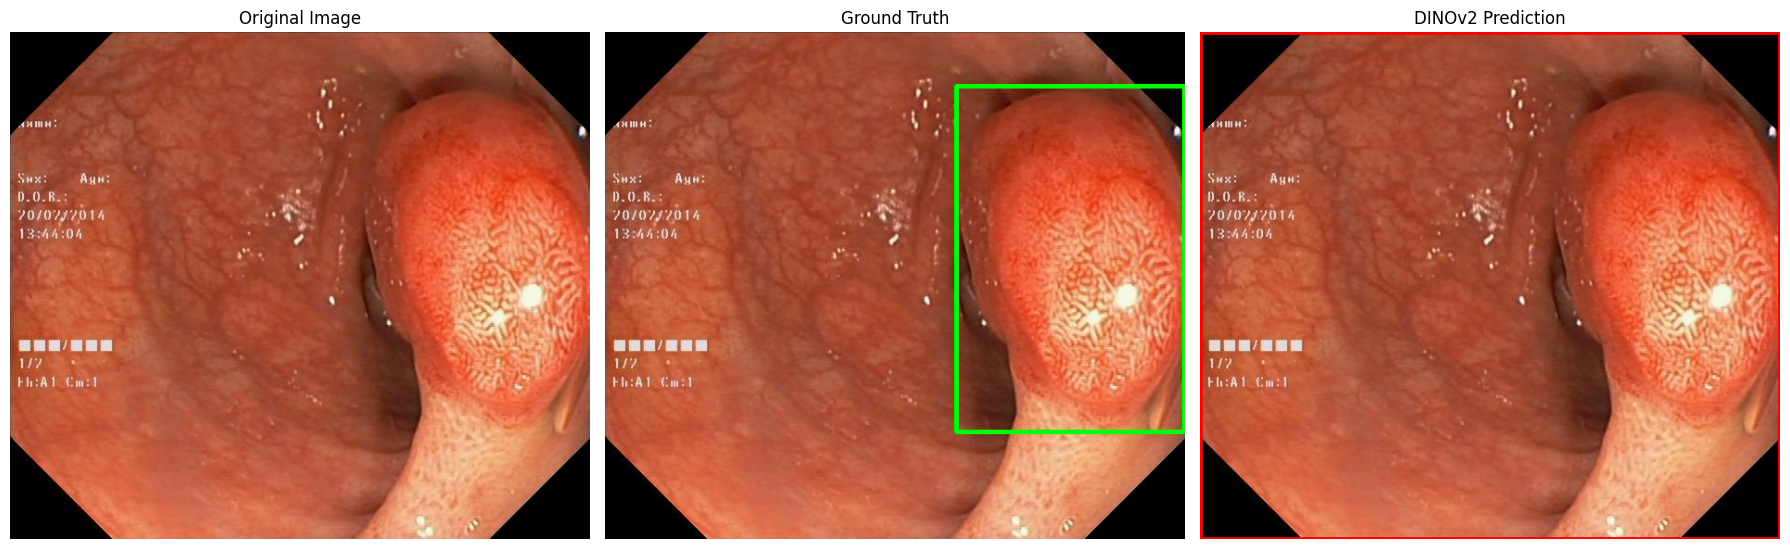

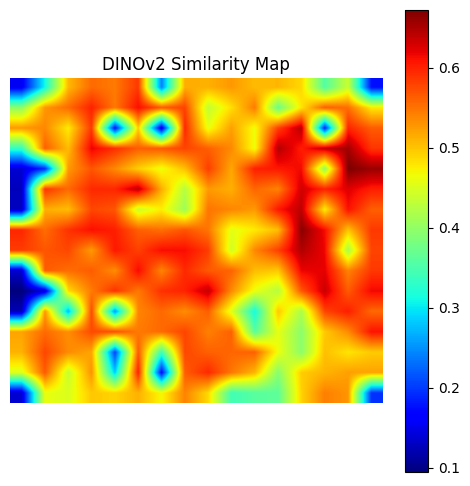


Ground Truth Boxes:
[[379, 58, 625, 431]]

Predicted Boxes:
[{'box': [0, 0, 626, 547], 'confidence': 0.672454297542572}]


In [1]:
# =========================================================
# DINOv2 Visualization:
# Original Image + Ground Truth + DINOv2 Prediction
# =========================================================

import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from transformers import AutoImageProcessor, AutoModel

# =========================================================
# CONFIG
# =========================================================
IMAGE_PATH = r"C:\Medical_image_analysis\yolov8_kvasir\images\train\cju0s2a9ekvms080138tjjpxr.jpg"

GT_PATH = r"C:\Medical_image_analysis\yolov8_kvasir\labels\train\cju0s2a9ekvms080138tjjpxr.txt"

REFERENCE_PATCH_DIR = r"C:\Users\Admin\MedSAM_Project\reference_patches"

MODEL_NAME = "facebook/dinov2-base"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

SIMILARITY_THRESH = 0.25
NMS_IOU_THRESH = 0.5

# =========================================================
# LOAD DINOv2
# =========================================================
print("Loading DINOv2...")

processor = AutoImageProcessor.from_pretrained(MODEL_NAME)

model = AutoModel.from_pretrained(MODEL_NAME)

model.to(DEVICE)
model.eval()

# =========================================================
# BUILD MULTI-REFERENCE FEATURE
# =========================================================
def build_reference():

    files = [
        f for f in os.listdir(REFERENCE_PATCH_DIR)
        if f.lower().endswith((".png", ".jpg", ".jpeg"))
    ]

    if len(files) == 0:
        raise ValueError("No reference patches found!")

    print(f"Using {len(files)} reference patches")

    feats = []

    for f in files:

        path = os.path.join(REFERENCE_PATCH_DIR, f)

        img = Image.open(path).convert("RGB")

        inputs = processor(
            images=img,
            return_tensors="pt"
        )

        pixel_values = inputs["pixel_values"].to(DEVICE)

        with torch.no_grad():

            outputs = model(pixel_values)

            # PATCH TOKENS ONLY
            patch_tokens = outputs.last_hidden_state.squeeze(0)[1:]

            feat = patch_tokens.mean(dim=0).cpu().numpy()

        feats.append(feat)

    ref = np.mean(np.stack(feats), axis=0)

    # SAFE NORMALIZATION
    ref = ref / (np.linalg.norm(ref) + 1e-8)

    return ref

# =========================================================
# EXTRACT PATCH FEATURES
# =========================================================
def get_patch_features(img_path):

    if not os.path.exists(img_path):
        raise FileNotFoundError(img_path)

    img = Image.open(img_path).convert("RGB")

    inputs = processor(
        images=img,
        return_tensors="pt"
    )

    pixel_values = inputs["pixel_values"].to(DEVICE)

    with torch.no_grad():

        outputs = model(pixel_values)

        patch_feats = outputs.last_hidden_state.squeeze(0)[1:]

    img_np = np.array(img)

    H, W = pixel_values.shape[-2:]

    patch_size = model.config.patch_size

    grid_h = H // patch_size
    grid_w = W // patch_size

    # =====================================================
    # PATCH GRID SAFETY FIX
    # =====================================================
    actual_patches = patch_feats.shape[0]

    expected = grid_h * grid_w

    if expected != actual_patches:

        print("\n[WARNING] Patch mismatch detected")
        print(f"Expected patches: {expected}")
        print(f"Actual patches:   {actual_patches}")

        grid_h = int(np.sqrt(actual_patches))
        grid_w = actual_patches // grid_h

        print(f"Recovered grid: {grid_h} x {grid_w}")

    return patch_feats, img_np, grid_h, grid_w

# =========================================================
# COSINE SIMILARITY
# =========================================================
def compute_similarity(patch_feats, ref):

    patch_feats = patch_feats.cpu().numpy()

    patch_feats = patch_feats / (
        np.linalg.norm(
            patch_feats,
            axis=1,
            keepdims=True
        ) + 1e-8
    )

    similarities = np.dot(patch_feats, ref)

    return similarities

# =========================================================
# IOU
# =========================================================
def iou(a, b):

    xA = max(a[0], b[0])
    yA = max(a[1], b[1])

    xB = min(a[2], b[2])
    yB = min(a[3], b[3])

    inter = max(0, xB - xA) * max(0, yB - yA)

    areaA = (a[2] - a[0]) * (a[3] - a[1])
    areaB = (b[2] - b[0]) * (b[3] - b[1])

    union = areaA + areaB - inter

    return inter / union if union > 0 else 0

# =========================================================
# NMS
# =========================================================
def nms(boxes):

    if len(boxes) == 0:
        return []

    boxes = sorted(
        boxes,
        key=lambda x: x['confidence'],
        reverse=True
    )

    keep = []

    for b in boxes:

        valid = True

        for k in keep:

            if iou(b['box'], k['box']) > NMS_IOU_THRESH:
                valid = False
                break

        if valid:
            keep.append(b)

    return keep

# =========================================================
# SIMILARITY -> BOXES
# =========================================================
def sim_to_boxes(
    similarities,
    h,
    w,
    grid_h,
    grid_w
):

    sim_map = similarities.reshape(grid_h, grid_w)

    sim_map_up = cv2.resize(sim_map, (w, h))

    mask = (
        sim_map_up > SIMILARITY_THRESH
    ).astype(np.uint8)

    contours, _ = cv2.findContours(
        mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    boxes = []

    for contour in contours:

        x, y, wc, hc = cv2.boundingRect(contour)

        conf = float(
            np.max(sim_map_up[y:y+hc, x:x+wc])
        )

        boxes.append({
            'box': [x, y, x + wc, y + hc],
            'confidence': conf
        })

    return boxes, sim_map_up

# =========================================================
# LOAD GT
# =========================================================
def load_gt(path, w, h):

    boxes = []

    if not os.path.exists(path):
        return boxes

    with open(path) as f:

        for line in f:

            parts = line.strip().split()

            if len(parts) != 5:
                continue

            _, cx, cy, bw, bh = map(float, parts)

            x1 = int((cx - bw/2) * w)
            y1 = int((cy - bh/2) * h)

            x2 = int((cx + bw/2) * w)
            y2 = int((cy + bh/2) * h)

            boxes.append([x1, y1, x2, y2])

    return boxes

# =========================================================
# MAIN PIPELINE
# =========================================================
print("\nBuilding reference features...")

ref = build_reference()

print("\nExtracting patch features...")

patch_feats, img_np, grid_h, grid_w = (
    get_patch_features(IMAGE_PATH)
)

h, w = img_np.shape[:2]

print("\nComputing similarity map...")

similarities = compute_similarity(
    patch_feats,
    ref
)

preds, sim_map = sim_to_boxes(
    similarities,
    h,
    w,
    grid_h,
    grid_w
)

preds = nms(preds)

# =========================================================
# TAKE HIGHEST CONFIDENCE BOX
# =========================================================
pred_box = None

if len(preds) > 0:

    pred_box = preds[0]['box']

# =========================================================
# LOAD GT
# =========================================================
gt_boxes = load_gt(GT_PATH, w, h)

# =========================================================
# VISUALIZATION IMAGES
# =========================================================
original = img_np.copy()

gt_img = img_np.copy()

pred_img = img_np.copy()

# DRAW GT BOXES
for gt in gt_boxes:

    cv2.rectangle(
        gt_img,
        (gt[0], gt[1]),
        (gt[2], gt[3]),
        (0, 255, 0),
        3
    )

# DRAW PREDICTION
if pred_box is not None:

    cv2.rectangle(
        pred_img,
        (pred_box[0], pred_box[1]),
        (pred_box[2], pred_box[3]),
        (255, 0, 0),
        3
    )

# =========================================================
# VISUALIZE
# =========================================================
plt.figure(figsize=(18, 6))

# Original
plt.subplot(1, 3, 1)

plt.imshow(original)

plt.title("Original Image")

plt.axis("off")

# GT
plt.subplot(1, 3, 2)

plt.imshow(gt_img)

plt.title("Ground Truth")

plt.axis("off")

# Prediction
plt.subplot(1, 3, 3)

plt.imshow(pred_img)

plt.title("DINOv2 Prediction")

plt.axis("off")

plt.tight_layout()

plt.show()

# =========================================================
# OPTIONAL: SHOW SIMILARITY MAP
# =========================================================
plt.figure(figsize=(6,6))

plt.imshow(sim_map, cmap='jet')

plt.title("DINOv2 Similarity Map")

plt.axis("off")

plt.colorbar()

plt.show()

# =========================================================
# PRINT RESULTS
# =========================================================
print("\nGround Truth Boxes:")
print(gt_boxes)

print("\nPredicted Boxes:")
print(preds)

Loading MedSAM...
Generating masks...


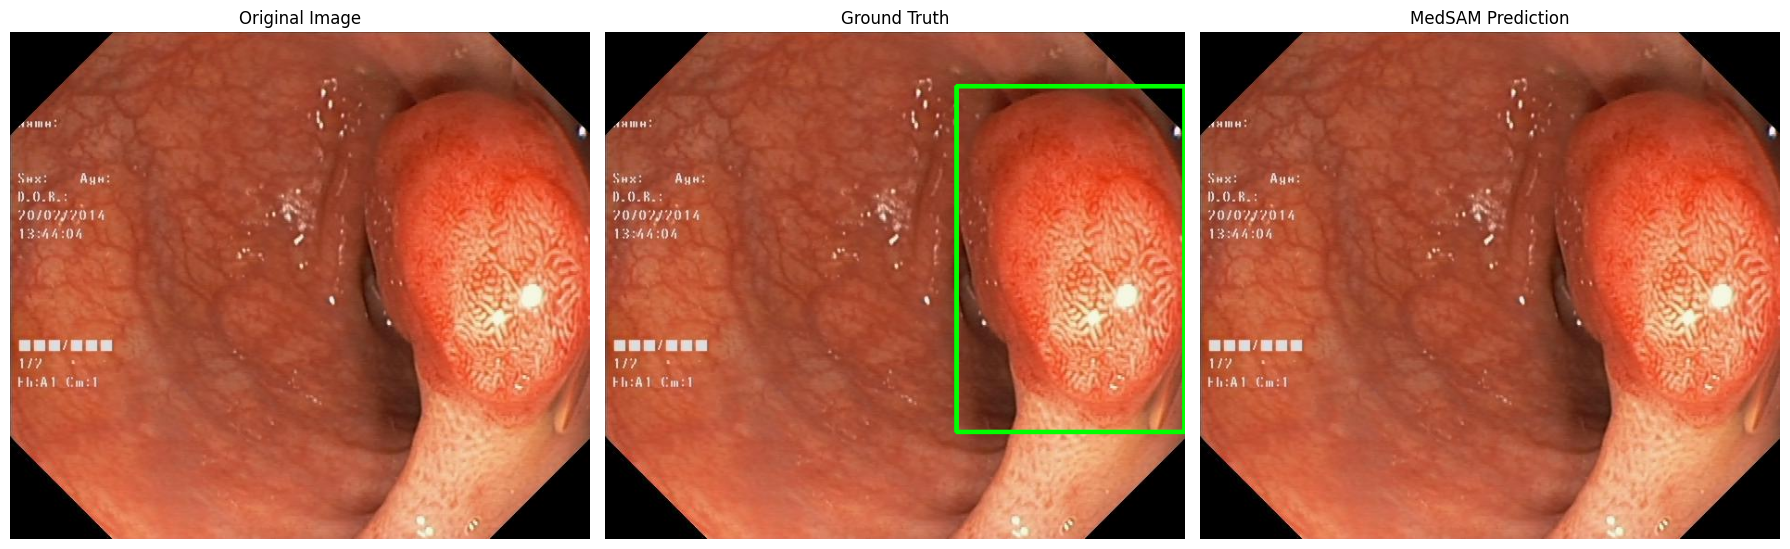


Ground Truth Boxes:
[[379, 58, 625, 431]]

Predicted Boxes:
[]


In [1]:
# =========================================================
# MEDSAM VISUALIZATION
# Original Image + Ground Truth + MedSAM Prediction
# =========================================================

import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

from segment_anything import (
    sam_model_registry,
    SamAutomaticMaskGenerator
)

# =========================================================
# CONFIG
# =========================================================
IMAGE_PATH = r"C:\Medical_image_analysis\yolov8_kvasir\images\train\cju0s2a9ekvms080138tjjpxr.jpg"

GT_PATH = r"C:\Medical_image_analysis\yolov8_kvasir\labels\train\cju0s2a9ekvms080138tjjpxr.txt"

CHECKPOINT = r"C:\Users\Admin\MedSAM_Project\medsam_vit_b.pth"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# =========================================================
# MEDSAM PARAMETERS
# =========================================================
POINTS_PER_SIDE = 32
PRED_IOU_THRESH = 0.4
STABILITY_SCORE_THRESH = 0.8
MIN_MASK_AREA = 100

# =========================================================
# POST PROCESSING
# =========================================================
CONF_THRESH = 0.3
NMS_IOU_THRESH = 0.5
MAX_DETECTIONS = 100

# =========================================================
# AREA FILTER
# =========================================================
MIN_POLYP_AREA_RATIO = 0.0005
MAX_POLYP_AREA_RATIO = 0.5

# =========================================================
# LOAD MEDSAM
# =========================================================
print("Loading MedSAM...")

sam = sam_model_registry["vit_b"](
    checkpoint=CHECKPOINT
)

sam.to(DEVICE)
sam.eval()

# =========================================================
# MASK GENERATOR
# =========================================================
mask_generator = SamAutomaticMaskGenerator(
    model=sam,
    points_per_side=POINTS_PER_SIDE,
    pred_iou_thresh=PRED_IOU_THRESH,
    stability_score_thresh=STABILITY_SCORE_THRESH,
    min_mask_region_area=MIN_MASK_AREA,
)

# =========================================================
# IOU
# =========================================================
def compute_iou(boxA, boxB):

    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])

    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    inter = max(0, xB - xA) * max(0, yB - yA)

    areaA = (
        (boxA[2] - boxA[0]) *
        (boxA[3] - boxA[1])
    )

    areaB = (
        (boxB[2] - boxB[0]) *
        (boxB[3] - boxB[1])
    )

    union = areaA + areaB - inter

    return inter / union if union > 0 else 0

# =========================================================
# MASK -> BOX
# =========================================================
def mask_to_box(mask):

    y, x = np.where(mask)

    if len(x) == 0:
        return None

    return [
        int(x.min()),
        int(y.min()),
        int(x.max()),
        int(y.max())
    ]

# =========================================================
# AREA FILTER
# =========================================================
def is_valid_polyp_box(box, h, w):

    area = (
        (box[2] - box[0]) *
        (box[3] - box[1])
    )

    img_area = h * w

    ratio = area / img_area

    return (
        MIN_POLYP_AREA_RATIO <
        ratio <
        MAX_POLYP_AREA_RATIO
    )

# =========================================================
# NMS
# =========================================================
def apply_nms(masks):

    if len(masks) == 0:
        return []

    masks = sorted(
        masks,
        key=lambda x: x.get(
            'stability_score',
            x['predicted_iou']
        ),
        reverse=True
    )

    keep = []
    keep_boxes = []

    for m in masks:

        box = mask_to_box(
            m['segmentation']
        )

        if box is None:
            continue

        valid = True

        for kb in keep_boxes:

            if compute_iou(box, kb) > NMS_IOU_THRESH:
                valid = False
                break

        if valid:

            keep.append(m)
            keep_boxes.append(box)

    return keep

# =========================================================
# LOAD GT BOX
# =========================================================
def load_gt(path, w, h):

    boxes = []

    with open(path) as f:

        for line in f:

            _, cx, cy, bw, bh = map(
                float,
                line.strip().split()
            )

            x1 = int((cx - bw/2) * w)
            y1 = int((cy - bh/2) * h)

            x2 = int((cx + bw/2) * w)
            y2 = int((cy + bh/2) * h)

            boxes.append([x1, y1, x2, y2])

    return boxes

# =========================================================
# LOAD IMAGE
# =========================================================
img_bgr = cv2.imread(IMAGE_PATH)

if img_bgr is None:
    raise ValueError("Image not found!")

img_rgb = cv2.cvtColor(
    img_bgr,
    cv2.COLOR_BGR2RGB
)

h, w = img_rgb.shape[:2]

# =========================================================
# LOAD GT
# =========================================================
gt_boxes = load_gt(GT_PATH, w, h)

# =========================================================
# GENERATE MASKS
# =========================================================
print("Generating masks...")

masks = mask_generator.generate(img_rgb)

# =========================================================
# CONFIDENCE FILTER
# =========================================================
filtered_masks = []

for m in masks:

    if m.get('predicted_iou', 0) > CONF_THRESH:

        filtered_masks.append(m)

# =========================================================
# APPLY NMS
# =========================================================
filtered_masks = apply_nms(filtered_masks)

filtered_masks = filtered_masks[:MAX_DETECTIONS]

# =========================================================
# CONVERT TO BOXES
# =========================================================
pred_boxes = []

for m in filtered_masks:

    box = mask_to_box(m["segmentation"])

    if (
        box and
        is_valid_polyp_box(box, h, w)
    ):

        pred_boxes.append({

            'box': box,

            'confidence': m.get(
                'stability_score',
                m['predicted_iou']
            )
        })

# =========================================================
# TAKE HIGHEST CONFIDENCE PREDICTION
# =========================================================
pred_box = None

if len(pred_boxes) > 0:

    pred_boxes = sorted(
        pred_boxes,
        key=lambda x: x['confidence'],
        reverse=True
    )

    pred_box = pred_boxes[0]['box']

# =========================================================
# VISUALIZATION IMAGES
# =========================================================
original = img_rgb.copy()

gt_img = img_rgb.copy()

pred_img = img_rgb.copy()

# =========================================================
# DRAW GT BOXES
# =========================================================
for gt in gt_boxes:

    cv2.rectangle(
        gt_img,
        (gt[0], gt[1]),
        (gt[2], gt[3]),
        (0, 255, 0),
        3
    )

# =========================================================
# DRAW PREDICTION
# =========================================================
if pred_box is not None:

    cv2.rectangle(
        pred_img,
        (pred_box[0], pred_box[1]),
        (pred_box[2], pred_box[3]),
        (255, 0, 0),
        3
    )

# =========================================================
# VISUALIZATION
# =========================================================
plt.figure(figsize=(18,6))

# ORIGINAL
plt.subplot(1,3,1)

plt.imshow(original)

plt.title("Original Image")

plt.axis("off")

# GT
plt.subplot(1,3,2)

plt.imshow(gt_img)

plt.title("Ground Truth")

plt.axis("off")

# PREDICTION
plt.subplot(1,3,3)

plt.imshow(pred_img)

plt.title("MedSAM Prediction")

plt.axis("off")

plt.tight_layout()

plt.show()

# =========================================================
# PRINT RESULTS
# =========================================================
print("\nGround Truth Boxes:")
print(gt_boxes)

print("\nPredicted Boxes:")
print(pred_boxes[:5])

In [3]:
!pip install git+https://github.com/facebookresearch/segment-anything.git

  Cloning https://github.com/facebookresearch/segment-anything.git to C:\Users\Admin\AppData\Local\Temp\pip-req-build-ucn_ggpg
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for segment_anything: filename=segment_anything-1.0-py3-none-any.whl size=36876 sha256=f2a333db9ecb4641c63e8184aec21033a83902db5a1af232fe98e896d4f51ed1
  Stored in directory: C:\Users\Admin\AppData\Local\Temp\pip-ephem-wheel-cache-z41pwjdw\wheels\10\cf\59\9ccb2f0a1bcc81d4fbd0e501680b5d088d690c6cfbc02dc99d
Successfully built segment_anything


  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git 'C:\Users\Admin\AppData\Local\Temp\pip-req-build-ucn_ggpg'


In [4]:
!pip install opencv-python matplotlib

Loading MedSAM...
Generating masks...
Total raw masks: 58
After confidence filtering: 58
After NMS: 39
Final prediction boxes: 29


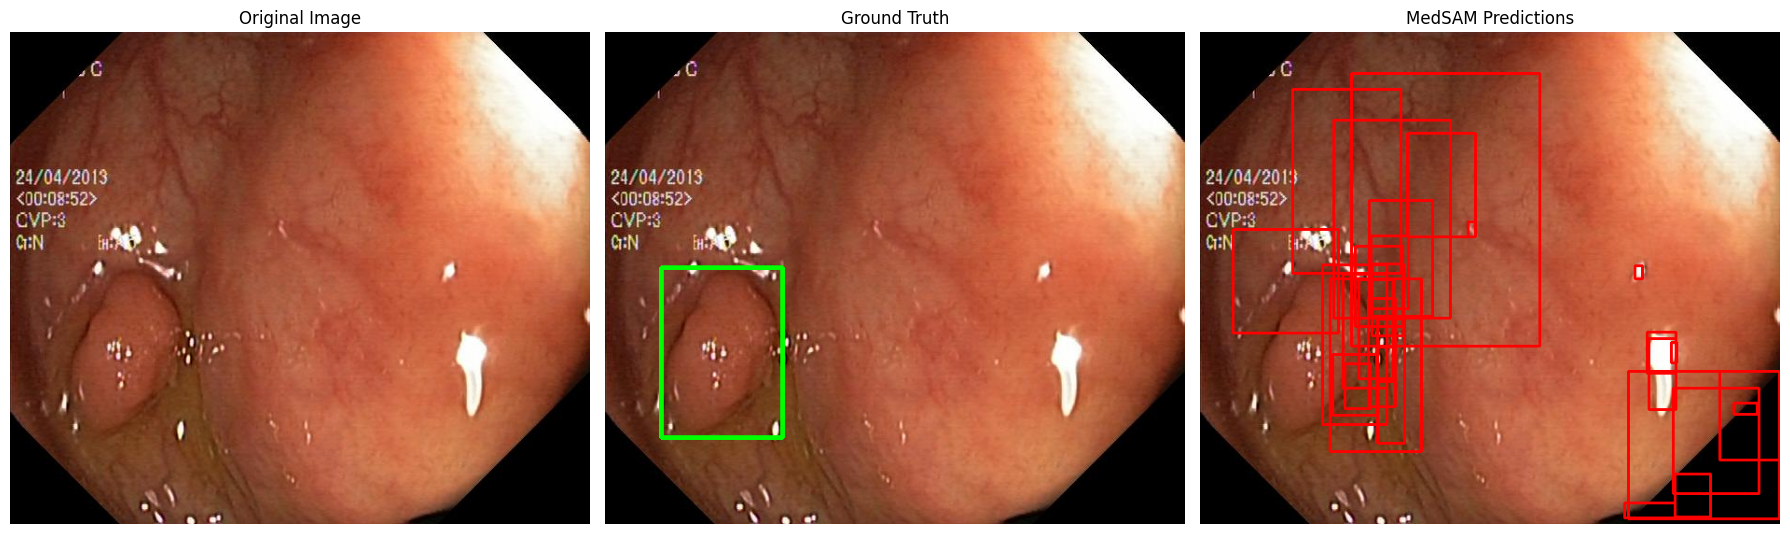


Ground Truth Boxes:
[[60, 253, 190, 435]]

Top Prediction Boxes:
[{'box': [459, 364, 621, 522], 'confidence': 0.6875132322311401}, {'box': [143, 95, 268, 307], 'confidence': 0.670093834400177}, {'box': [99, 62, 215, 259], 'confidence': 0.6527811884880066}, {'box': [35, 212, 148, 323], 'confidence': 0.602685272693634}, {'box': [166, 230, 217, 316], 'confidence': 0.5927419066429138}, {'box': [190, 338, 208, 375], 'confidence': 0.5891719460487366}, {'box': [479, 322, 510, 366], 'confidence': 0.5690759420394897}, {'box': [139, 265, 237, 450], 'confidence': 0.5678437948226929}, {'box': [155, 356, 182, 404], 'confidence': 0.5648415088653564}, {'box': [557, 364, 621, 459], 'confidence': 0.5616359710693359}]


In [25]:
# =========================================================
# MEDSAM VISUALIZATION (RELAXED FOR QUALITATIVE ANALYSIS)
# Original Image + Ground Truth + MedSAM Predictions
# =========================================================

import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

from segment_anything import (
    sam_model_registry,
    SamAutomaticMaskGenerator
)

# =========================================================
# CONFIG
# =========================================================
IMAGE_PATH = r"C:\Medical_image_analysis\yolov8_kvasir\images\train\cju2phaksnahz0993yxogjcpv.jpg"

GT_PATH = r"C:\Medical_image_analysis\yolov8_kvasir\labels\train\cju2phaksnahz0993yxogjcpv.txt"

CHECKPOINT = r"C:\Users\Admin\MedSAM_Project\medsam_vit_b.pth"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# =========================================================
# RELAXED PARAMETERS FOR VISUALIZATION ONLY
# =========================================================
POINTS_PER_SIDE = 32

PRED_IOU_THRESH = 0.2
STABILITY_SCORE_THRESH = 0.5

MIN_MASK_AREA = 50

CONF_THRESH = 0.1

NMS_IOU_THRESH = 0.5

MAX_DETECTIONS = 100

# =========================================================
# AREA FILTER
# =========================================================
MIN_POLYP_AREA_RATIO = 0.0001
MAX_POLYP_AREA_RATIO = 0.8

# =========================================================
# LOAD MEDSAM
# =========================================================
print("Loading MedSAM...")

sam = sam_model_registry["vit_b"](
    checkpoint=CHECKPOINT
)

sam.to(DEVICE)
sam.eval()

# =========================================================
# MASK GENERATOR
# =========================================================
mask_generator = SamAutomaticMaskGenerator(
    model=sam,
    points_per_side=POINTS_PER_SIDE,
    pred_iou_thresh=PRED_IOU_THRESH,
    stability_score_thresh=STABILITY_SCORE_THRESH,
    min_mask_region_area=MIN_MASK_AREA,
)

# =========================================================
# IOU
# =========================================================
def compute_iou(boxA, boxB):

    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])

    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    inter = max(0, xB - xA) * max(0, yB - yA)

    areaA = (
        (boxA[2] - boxA[0]) *
        (boxA[3] - boxA[1])
    )

    areaB = (
        (boxB[2] - boxB[0]) *
        (boxB[3] - boxB[1])
    )

    union = areaA + areaB - inter

    return inter / union if union > 0 else 0

# =========================================================
# MASK -> BOX
# =========================================================
def mask_to_box(mask):

    y, x = np.where(mask)

    if len(x) == 0:
        return None

    return [
        int(x.min()),
        int(y.min()),
        int(x.max()),
        int(y.max())
    ]

# =========================================================
# AREA FILTER
# =========================================================
def is_valid_polyp_box(box, h, w):

    area = (
        (box[2] - box[0]) *
        (box[3] - box[1])
    )

    img_area = h * w

    ratio = area / img_area

    return (
        MIN_POLYP_AREA_RATIO <
        ratio <
        MAX_POLYP_AREA_RATIO
    )

# =========================================================
# NMS
# =========================================================
def apply_nms(masks):

    if len(masks) == 0:
        return []

    masks = sorted(
        masks,
        key=lambda x: x.get(
            'stability_score',
            x['predicted_iou']
        ),
        reverse=True
    )

    keep = []
    keep_boxes = []

    for m in masks:

        box = mask_to_box(
            m['segmentation']
        )

        if box is None:
            continue

        valid = True

        for kb in keep_boxes:

            if compute_iou(box, kb) > NMS_IOU_THRESH:
                valid = False
                break

        if valid:

            keep.append(m)
            keep_boxes.append(box)

    return keep

# =========================================================
# LOAD GT BOXES
# =========================================================
def load_gt(path, w, h):

    boxes = []

    with open(path) as f:

        for line in f:

            _, cx, cy, bw, bh = map(
                float,
                line.strip().split()
            )

            x1 = int((cx - bw/2) * w)
            y1 = int((cy - bh/2) * h)

            x2 = int((cx + bw/2) * w)
            y2 = int((cy + bh/2) * h)

            boxes.append([x1, y1, x2, y2])

    return boxes

# =========================================================
# LOAD IMAGE
# =========================================================
img_bgr = cv2.imread(IMAGE_PATH)

if img_bgr is None:
    raise ValueError("Image not found!")

img_rgb = cv2.cvtColor(
    img_bgr,
    cv2.COLOR_BGR2RGB
)

h, w = img_rgb.shape[:2]

# =========================================================
# LOAD GT
# =========================================================
gt_boxes = load_gt(GT_PATH, w, h)

# =========================================================
# GENERATE MASKS
# =========================================================
print("Generating masks...")

masks = mask_generator.generate(img_rgb)

print(f"Total raw masks: {len(masks)}")

# =========================================================
# FILTER MASKS
# =========================================================
filtered_masks = []

for m in masks:

    if m.get('predicted_iou', 0) > CONF_THRESH:

        filtered_masks.append(m)

print(f"After confidence filtering: {len(filtered_masks)}")

# =========================================================
# APPLY NMS
# =========================================================
filtered_masks = apply_nms(filtered_masks)

print(f"After NMS: {len(filtered_masks)}")

filtered_masks = filtered_masks[:MAX_DETECTIONS]

# =========================================================
# CONVERT TO BOXES
# =========================================================
pred_boxes = []

for m in filtered_masks:

    box = mask_to_box(
        m["segmentation"]
    )

    if (
        box and
        is_valid_polyp_box(box, h, w)
    ):

        pred_boxes.append({

            'box': box,

            'confidence': m.get(
                'stability_score',
                m['predicted_iou']
            )
        })

print(f"Final prediction boxes: {len(pred_boxes)}")

# =========================================================
# VISUALIZATION IMAGES
# =========================================================
original = img_rgb.copy()

gt_img = img_rgb.copy()

pred_img = img_rgb.copy()

# =========================================================
# DRAW GT BOXES (GREEN)
# =========================================================
for gt in gt_boxes:

    cv2.rectangle(
        gt_img,
        (gt[0], gt[1]),
        (gt[2], gt[3]),
        (0, 255, 0),
        3
    )

# =========================================================
# DRAW ALL PREDICTIONS (RED)
# =========================================================
for p in pred_boxes:

    box = p['box']

    cv2.rectangle(
        pred_img,
        (box[0], box[1]),
        (box[2], box[3]),
        (255, 0, 0),
        2
    )

# =========================================================
# VISUALIZATION
# =========================================================
plt.figure(figsize=(18,6))

# ORIGINAL
plt.subplot(1,3,1)

plt.imshow(original)

plt.title("Original Image")

plt.axis("off")

# GT
plt.subplot(1,3,2)

plt.imshow(gt_img)

plt.title("Ground Truth")

plt.axis("off")

# PREDICTION
plt.subplot(1,3,3)

plt.imshow(pred_img)

plt.title("MedSAM Predictions")

plt.axis("off")

plt.tight_layout()

plt.show()

# =========================================================
# PRINT RESULTS
# =========================================================
print("\nGround Truth Boxes:")
print(gt_boxes)

print("\nTop Prediction Boxes:")
print(pred_boxes[:10])

Loading DINOv2...


Loading weights: 100%|██████████| 223/223 [00:00<00:00, 4532.08it/s]



Building reference features...
Using 6 reference patches

Extracting patch features...

Computing similarity map...


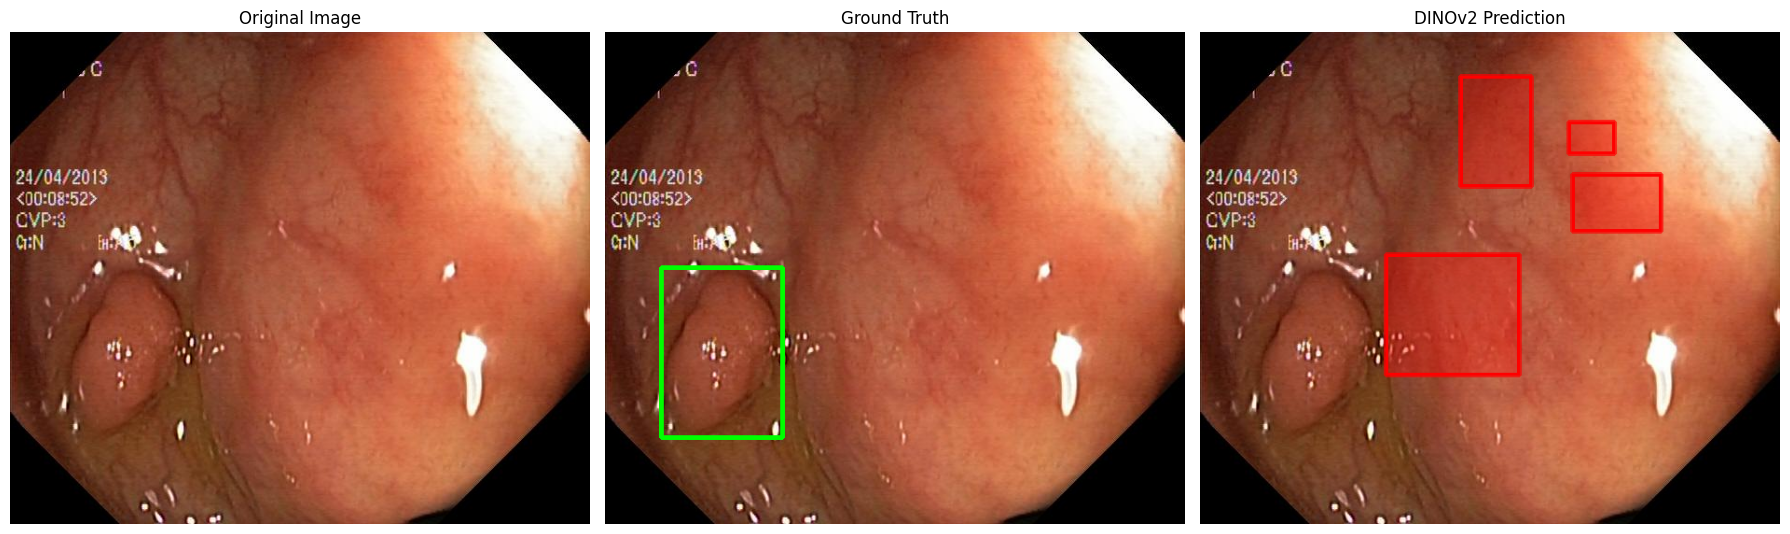


Visualization complete!


In [26]:
# =========================================================
# CLEAN DINOv2 POLYP LOCALIZATION VISUALIZATION
# Original + GT + Localized DINOv2 Prediction
# =========================================================

import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from transformers import AutoImageProcessor, AutoModel

# =========================================================
# CONFIG
# =========================================================
IMAGE_PATH = r"C:\Medical_image_analysis\yolov8_kvasir\images\train\cju2phaksnahz0993yxogjcpv.jpg"

GT_PATH = r"C:\Medical_image_analysis\yolov8_kvasir\labels\train\cju2phaksnahz0993yxogjcpv.txt"

REFERENCE_PATCH_DIR = r"C:\Users\Admin\MedSAM_Project\reference_patches"

MODEL_NAME = "facebook/dinov2-base"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# =========================================================
# LOAD DINOv2
# =========================================================
print("Loading DINOv2...")

processor = AutoImageProcessor.from_pretrained(
    MODEL_NAME
)

model = AutoModel.from_pretrained(
    MODEL_NAME
)

model.to(DEVICE)

model.eval()

# =========================================================
# BUILD MULTI-REFERENCE FEATURE
# =========================================================
def build_reference():

    files = [

        f for f in os.listdir(
            REFERENCE_PATCH_DIR
        )

        if f.lower().endswith(
            (".png", ".jpg", ".jpeg")
        )
    ]

    if len(files) == 0:

        raise ValueError(
            "No reference patches found!"
        )

    print(
        f"Using {len(files)} reference patches"
    )

    feats = []

    for f in files:

        path = os.path.join(
            REFERENCE_PATCH_DIR,
            f
        )

        img = Image.open(path).convert("RGB")

        inputs = processor(
            images=img,
            return_tensors="pt"
        )

        pixel_values = inputs[
            "pixel_values"
        ].to(DEVICE)

        with torch.no_grad():

            outputs = model(pixel_values)

            patch_tokens = (
                outputs
                .last_hidden_state
                .squeeze(0)[1:]
            )

            feat = (
                patch_tokens
                .mean(dim=0)
                .cpu()
                .numpy()
            )

        feats.append(feat)

    ref = np.mean(
        np.stack(feats),
        axis=0
    )

    ref = ref / (
        np.linalg.norm(ref) + 1e-8
    )

    return ref

# =========================================================
# EXTRACT PATCH FEATURES
# =========================================================
def get_patch_features(img_path):

    img = Image.open(img_path).convert("RGB")

    inputs = processor(
        images=img,
        return_tensors="pt"
    )

    pixel_values = inputs[
        "pixel_values"
    ].to(DEVICE)

    with torch.no_grad():

        outputs = model(pixel_values)

        patch_feats = (
            outputs
            .last_hidden_state
            .squeeze(0)[1:]
        )

    img_np = np.array(img)

    H, W = pixel_values.shape[-2:]

    patch_size = model.config.patch_size

    grid_h = H // patch_size
    grid_w = W // patch_size

    # =====================================================
    # PATCH SAFETY FIX
    # =====================================================
    actual_patches = patch_feats.shape[0]

    expected = grid_h * grid_w

    if expected != actual_patches:

        print(
            "Patch mismatch detected"
        )

        grid_h = int(
            np.sqrt(actual_patches)
        )

        grid_w = (
            actual_patches // grid_h
        )

    return (
        patch_feats,
        img_np,
        grid_h,
        grid_w
    )

# =========================================================
# COSINE SIMILARITY
# =========================================================
def compute_similarity(
    patch_feats,
    ref
):

    patch_feats = (
        patch_feats
        .cpu()
        .numpy()
    )

    patch_feats = patch_feats / (

        np.linalg.norm(
            patch_feats,
            axis=1,
            keepdims=True
        ) + 1e-8
    )

    sim = np.dot(
        patch_feats,
        ref
    )

    return sim

# =========================================================
# LOAD GT
# =========================================================
def load_gt(path, w, h):

    boxes = []

    with open(path) as f:

        for line in f:

            _, cx, cy, bw, bh = map(
                float,
                line.strip().split()
            )

            x1 = int(
                (cx - bw/2) * w
            )

            y1 = int(
                (cy - bh/2) * h
            )

            x2 = int(
                (cx + bw/2) * w
            )

            y2 = int(
                (cy + bh/2) * h
            )

            boxes.append([
                x1,
                y1,
                x2,
                y2
            ])

    return boxes

# =========================================================
# MAIN
# =========================================================
print(
    "\nBuilding reference features..."
)

ref = build_reference()

print(
    "\nExtracting patch features..."
)

(
    patch_feats,
    img_np,
    grid_h,
    grid_w

) = get_patch_features(
    IMAGE_PATH
)

h, w = img_np.shape[:2]

print(
    "\nComputing similarity map..."
)

similarities = compute_similarity(
    patch_feats,
    ref
)

# =========================================================
# SIMILARITY MAP
# =========================================================
sim_map = similarities.reshape(
    grid_h,
    grid_w
)

sim_map = cv2.resize(
    sim_map,
    (w, h)
)

# =========================================================
# NORMALIZE
# =========================================================
sim_norm = cv2.normalize(
    sim_map,
    None,
    0,
    255,
    cv2.NORM_MINMAX
).astype(np.uint8)

# =========================================================
# HIGH ACTIVATION THRESHOLD
# =========================================================
threshold = np.percentile(
    sim_norm,
    92
)

binary_mask = (
    sim_norm > threshold
).astype(np.uint8)

# =========================================================
# MORPHOLOGICAL CLEANING
# =========================================================
kernel = np.ones((15,15), np.uint8)

binary_mask = cv2.morphologyEx(
    binary_mask,
    cv2.MORPH_OPEN,
    kernel
)

binary_mask = cv2.morphologyEx(
    binary_mask,
    cv2.MORPH_CLOSE,
    kernel
)

# =========================================================
# FIND CONTOURS
# =========================================================
contours, _ = cv2.findContours(
    binary_mask,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

# =========================================================
# LOAD GT
# =========================================================
gt_boxes = load_gt(
    GT_PATH,
    w,
    h
)

# =========================================================
# VISUALIZATION IMAGES
# =========================================================
original = img_np.copy()

gt_img = img_np.copy()

dino_img = img_np.copy()

overlay = img_np.copy()

# =========================================================
# DRAW GT
# =========================================================
for gt in gt_boxes:

    cv2.rectangle(
        gt_img,
        (gt[0], gt[1]),
        (gt[2], gt[3]),
        (0,255,0),
        3
    )

# =========================================================
# DRAW DINOv2 ACTIVATIONS
# =========================================================
for cnt in contours:

    area = cv2.contourArea(cnt)

    # remove noisy regions
    if area < 1000:
        continue

    x, y, bw, bh = cv2.boundingRect(cnt)

    # RED OVERLAY
    cv2.rectangle(
        overlay,
        (x, y),
        (x+bw, y+bh),
        (255,0,0),
        -1
    )

    # RED BORDER
    cv2.rectangle(
        dino_img,
        (x, y),
        (x+bw, y+bh),
        (255,0,0),
        3
    )

# =========================================================
# BLEND OVERLAY
# =========================================================
dino_img = cv2.addWeighted(
    overlay,
    0.30,
    dino_img,
    0.70,
    0
)


# =========================================================
# VISUALIZATION
# =========================================================
plt.figure(figsize=(18,6))

# ORIGINAL
plt.subplot(1,3,1)

plt.imshow(original)

plt.title("Original Image")

plt.axis("off")

# GT
plt.subplot(1,3,2)

plt.imshow(gt_img)

plt.title("Ground Truth")

plt.axis("off")

# DINOv2
plt.subplot(1,3,3)

plt.imshow(dino_img)

plt.title("DINOv2 Prediction")

plt.axis("off")

plt.tight_layout()

plt.show()

print("\nVisualization complete!")

Loading YOLOv8 model...
Running YOLOv8 inference...
Detected boxes: 1


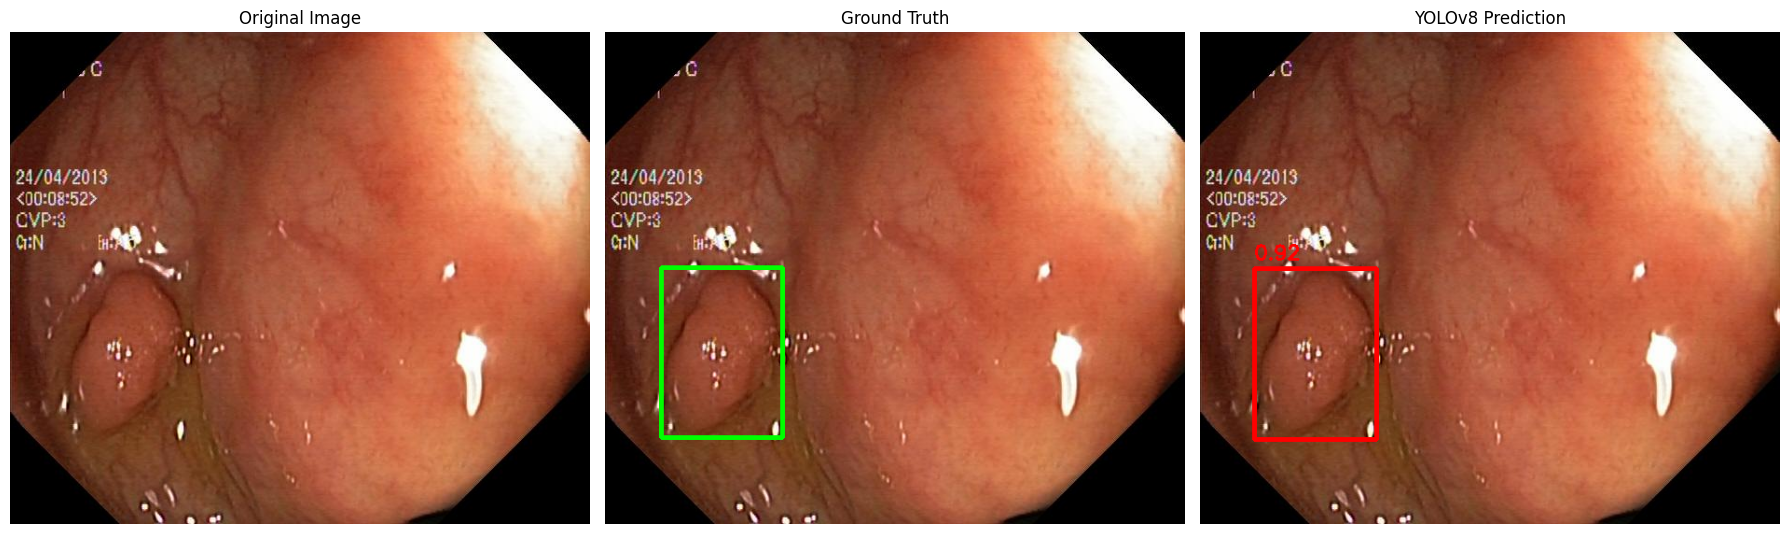


Ground Truth Boxes:
[[60, 253, 190, 435]]

Predicted Boxes:
[{'box': [58, 254, 189, 437], 'conf': 0.9246666431427002}]


In [28]:
# =========================================================
# YOLOv8 POLYP DETECTION VISUALIZATION
# Original + Ground Truth + YOLOv8 Prediction
# =========================================================

import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

from ultralytics import YOLO

# =========================================================
# CONFIG
# =========================================================
IMAGE_PATH = r"C:\Medical_image_analysis\yolov8_kvasir\images\train\cju2phaksnahz0993yxogjcpv.jpg"

GT_PATH = r"C:\Medical_image_analysis\yolov8_kvasir\labels\train\cju2phaksnahz0993yxogjcpv.txt"

MODEL_PATH = r"C:\Medical_image_analysis\yolov8_kvasir\results\YOLOv8\kvasir-seg_augmentation_10_percent_negative_yolov8\yolov8l_kvasir_train_25_06\weights\best.pt"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

CONF_THRESH = 0.25

# =========================================================
# LOAD YOLOv8 MODEL
# =========================================================
print("Loading YOLOv8 model...")

model = YOLO(MODEL_PATH)

# =========================================================
# LOAD IMAGE
# =========================================================
img_bgr = cv2.imread(IMAGE_PATH)

if img_bgr is None:
    raise ValueError("Image not found!")

img_rgb = cv2.cvtColor(
    img_bgr,
    cv2.COLOR_BGR2RGB
)

h, w = img_rgb.shape[:2]

# =========================================================
# LOAD GT BOXES
# =========================================================
def load_gt(path, w, h):

    boxes = []

    with open(path) as f:

        for line in f:

            _, cx, cy, bw, bh = map(
                float,
                line.strip().split()
            )

            x1 = int((cx - bw/2) * w)
            y1 = int((cy - bh/2) * h)

            x2 = int((cx + bw/2) * w)
            y2 = int((cy + bh/2) * h)

            boxes.append([
                x1,
                y1,
                x2,
                y2
            ])

    return boxes

gt_boxes = load_gt(
    GT_PATH,
    w,
    h
)

# =========================================================
# YOLOv8 INFERENCE
# =========================================================
print("Running YOLOv8 inference...")

results = model.predict(
    source=IMAGE_PATH,
    conf=CONF_THRESH,
    device=0 if DEVICE == "cuda" else "cpu",
    verbose=False
)

# =========================================================
# EXTRACT PREDICTIONS
# =========================================================
pred_boxes = []

for r in results:

    if r.boxes is None:
        continue

    boxes = r.boxes.xyxy.cpu().numpy()
    confs = r.boxes.conf.cpu().numpy()

    for box, conf in zip(boxes, confs):

        x1, y1, x2, y2 = map(int, box)

        pred_boxes.append({

            "box": [x1, y1, x2, y2],
            "conf": float(conf)

        })

print(f"Detected boxes: {len(pred_boxes)}")

# =========================================================
# VISUALIZATION IMAGES
# =========================================================
original = img_rgb.copy()

gt_img = img_rgb.copy()

pred_img = img_rgb.copy()

# =========================================================
# DRAW GT BOXES (GREEN)
# =========================================================
for gt in gt_boxes:

    cv2.rectangle(
        gt_img,
        (gt[0], gt[1]),
        (gt[2], gt[3]),
        (0,255,0),
        3
    )

# =========================================================
# DRAW YOLO PREDICTIONS (RED)
# =========================================================
for p in pred_boxes:

    box = p["box"]
    conf = p["conf"]

    cv2.rectangle(
        pred_img,
        (box[0], box[1]),
        (box[2], box[3]),
        (255,0,0),
        3
    )

    cv2.putText(
        pred_img,
        f"{conf:.2f}",
        (box[0], box[1]-10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (255,0,0),
        2
    )

# =========================================================
# VISUALIZATION
# =========================================================
plt.figure(figsize=(18,6))

# ORIGINAL
plt.subplot(1,3,1)

plt.imshow(original)

plt.title("Original Image")

plt.axis("off")

# GT
plt.subplot(1,3,2)

plt.imshow(gt_img)

plt.title("Ground Truth")

plt.axis("off")

# YOLOv8 PREDICTION
plt.subplot(1,3,3)

plt.imshow(pred_img)

plt.title("YOLOv8 Prediction")

plt.axis("off")

plt.tight_layout()

plt.show()

# =========================================================
# PRINT RESULTS
# =========================================================
print("\nGround Truth Boxes:")
print(gt_boxes)

print("\nPredicted Boxes:")
print(pred_boxes)

Loading YOLOv12 model...
Running YOLOv12 inference...
Detected boxes: 1


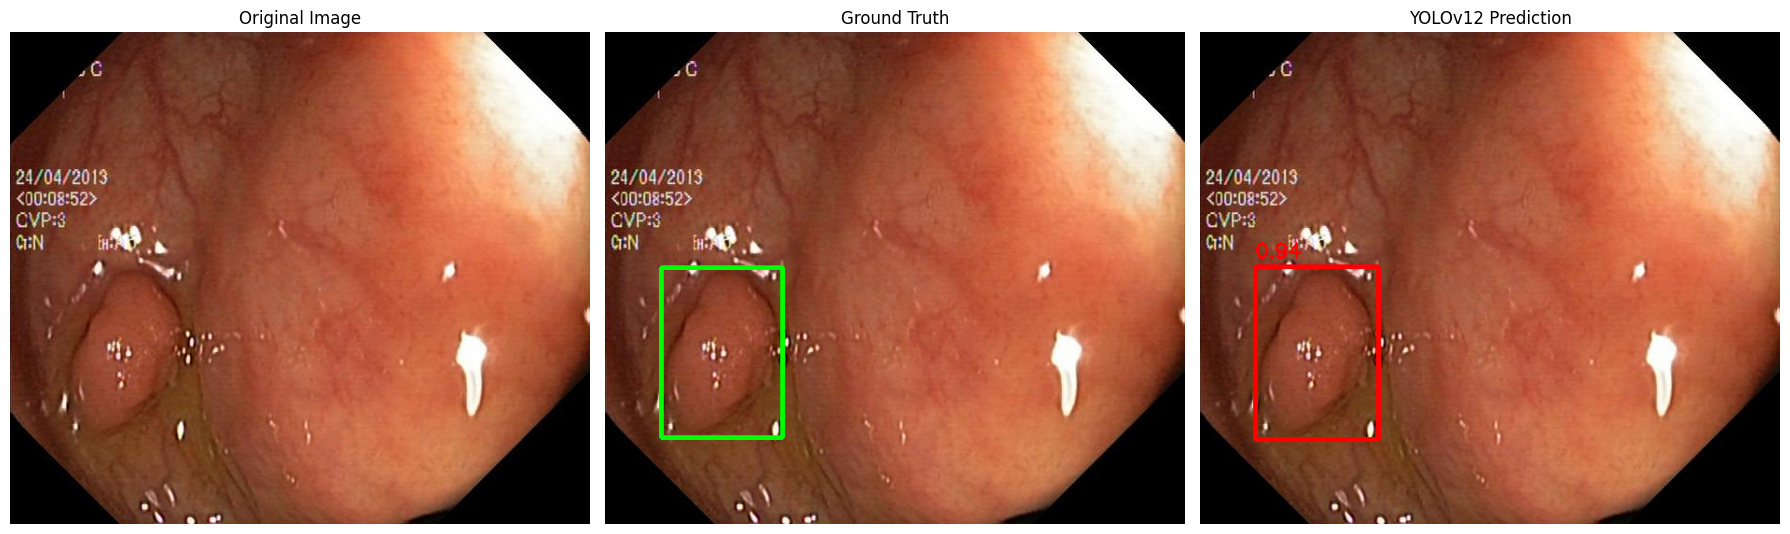


Ground Truth Boxes:
[[60, 253, 190, 435]]

Predicted Boxes:
[{'box': [59, 252, 191, 437], 'conf': 0.938648521900177}]


In [29]:
# =========================================================
# YOLOv12 POLYP DETECTION VISUALIZATION
# Original + Ground Truth + YOLOv12 Prediction
# =========================================================

import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

from ultralytics import YOLO

# =========================================================
# CONFIG
# =========================================================
IMAGE_PATH = r"C:\Medical_image_analysis\yolov8_kvasir\images\train\cju2phaksnahz0993yxogjcpv.jpg"

GT_PATH = r"C:\Medical_image_analysis\yolov8_kvasir\labels\train\cju2phaksnahz0993yxogjcpv.txt"

MODEL_PATH = r"C:\Medical_image_analysis\yolov8_kvasir\results\YOLOv12\YOLOv12_kvasir-seg_dataset_with_augmentations_10_negative\yolov12_l_kvasir_with_augmen_10_negative3\weights\best.pt"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

CONF_THRESH = 0.25

# =========================================================
# LOAD YOLOv12 MODEL
# =========================================================
print("Loading YOLOv12 model...")

model = YOLO(MODEL_PATH)

# =========================================================
# LOAD IMAGE
# =========================================================
img_bgr = cv2.imread(IMAGE_PATH)

if img_bgr is None:
    raise ValueError("Image not found!")

img_rgb = cv2.cvtColor(
    img_bgr,
    cv2.COLOR_BGR2RGB
)

h, w = img_rgb.shape[:2]

# =========================================================
# LOAD GT BOXES
# =========================================================
def load_gt(path, w, h):

    boxes = []

    with open(path) as f:

        for line in f:

            _, cx, cy, bw, bh = map(
                float,
                line.strip().split()
            )

            x1 = int((cx - bw/2) * w)
            y1 = int((cy - bh/2) * h)

            x2 = int((cx + bw/2) * w)
            y2 = int((cy + bh/2) * h)

            boxes.append([
                x1,
                y1,
                x2,
                y2
            ])

    return boxes

gt_boxes = load_gt(
    GT_PATH,
    w,
    h
)

# =========================================================
# YOLOv12 INFERENCE
# =========================================================
print("Running YOLOv12 inference...")

results = model.predict(
    source=IMAGE_PATH,
    conf=CONF_THRESH,
    device=0 if DEVICE == "cuda" else "cpu",
    verbose=False
)

# =========================================================
# EXTRACT PREDICTIONS
# =========================================================
pred_boxes = []

for r in results:

    if r.boxes is None:
        continue

    boxes = r.boxes.xyxy.cpu().numpy()
    confs = r.boxes.conf.cpu().numpy()

    for box, conf in zip(boxes, confs):

        x1, y1, x2, y2 = map(int, box)

        pred_boxes.append({

            "box": [x1, y1, x2, y2],
            "conf": float(conf)

        })

print(f"Detected boxes: {len(pred_boxes)}")

# =========================================================
# VISUALIZATION IMAGES
# =========================================================
original = img_rgb.copy()

gt_img = img_rgb.copy()

pred_img = img_rgb.copy()

# =========================================================
# DRAW GT BOXES (GREEN)
# =========================================================
for gt in gt_boxes:

    cv2.rectangle(
        gt_img,
        (gt[0], gt[1]),
        (gt[2], gt[3]),
        (0,255,0),
        3
    )

# =========================================================
# DRAW YOLOv12 PREDICTIONS (RED)
# =========================================================
for p in pred_boxes:

    box = p["box"]
    conf = p["conf"]

    cv2.rectangle(
        pred_img,
        (box[0], box[1]),
        (box[2], box[3]),
        (255,0,0),
        3
    )

    cv2.putText(
        pred_img,
        f"{conf:.2f}",
        (box[0], box[1]-10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (255,0,0),
        2
    )

# =========================================================
# VISUALIZATION
# =========================================================
plt.figure(figsize=(18,6))

# ORIGINAL
plt.subplot(1,3,1)

plt.imshow(original)

plt.title("Original Image")

plt.axis("off")

# GT
plt.subplot(1,3,2)

plt.imshow(gt_img)

plt.title("Ground Truth")

plt.axis("off")

# YOLOv12 PREDICTION
plt.subplot(1,3,3)

plt.imshow(pred_img)

plt.title("YOLOv12 Prediction")

plt.axis("off")

plt.tight_layout()

plt.show()

# =========================================================
# PRINT RESULTS
# =========================================================
print("\nGround Truth Boxes:")
print(gt_boxes)

print("\nPredicted Boxes:")
print(pred_boxes)

In [9]:
# =========================================================
# FPS BENCHMARKING SCRIPT
# YOLOv8-L vs YOLOv12-L vs MedSAM vs DINOv2
# =========================================================

import os
import time
import cv2
import torch
import numpy as np

from ultralytics import YOLO
from transformers import AutoImageProcessor, AutoModel
from segment_anything import (
    sam_model_registry,
    SamAutomaticMaskGenerator
)

# =========================================================
# CONFIG
# =========================================================
IMAGE_DIR = r"C:\Medical_image_analysis\yolov8_kvasir\images\test"

YOLOV8_PATH = r"C:\Medical_image_analysis\yolov8_kvasir\results\YOLOv8\kvasir-seg_augmentation_10_percent_negative_yolov8\yolov8l_kvasir_train_25_06\weights\best.pt"

YOLOV12_PATH = r"C:\Medical_image_analysis\yolov8_kvasir\results\YOLOv12\YOLOv12_kvasir-seg_dataset_with_augmentations_10_negative\yolov12_l_kvasir_with_augmen_10_negative3\weights\best.pt"

MEDSAM_CHECKPOINT = r"C:\Users\Admin\MedSAM_Project\medsam_vit_b.pth"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

NUM_IMAGES = 100

# =========================================================
# LOAD TEST IMAGES
# =========================================================
images = [

    os.path.join(IMAGE_DIR, f)

    for f in os.listdir(IMAGE_DIR)

    if f.lower().endswith(
        (".jpg", ".png", ".jpeg")
    )
]

images = sorted(images)[:NUM_IMAGES]

print(f"\nUsing {len(images)} images")

# =========================================================
# GPU SYNC TIMER
# =========================================================
def sync():

    if torch.cuda.is_available():
        torch.cuda.synchronize()

# =========================================================
# BENCHMARK FUNCTION
# =========================================================
def benchmark_model(
    name,
    inference_function
):

    print(f"\n{name}")

    # =====================================================
    # WARMUP
    # =====================================================
    print("Warmup...")

    for i in range(5):

        inference_function(images[i])

    sync()

    # =====================================================
    # TIMING
    # =====================================================
    print("Benchmarking...")

    start = time.time()

    for img_path in images:

        inference_function(img_path)

    sync()

    end = time.time()

    total_time = end - start

    avg_time = total_time / len(images)

    fps = 1.0 / avg_time

    print(f"Total Time      : {total_time:.4f} sec")
    print(f"Avg/Image Time  : {avg_time:.4f} sec")
    print(f"FPS             : {fps:.2f}")

    return {

        "model": name,
        "total_time": total_time,
        "avg_time": avg_time,
        "fps": fps
    }

# =========================================================
# YOLOv8
# =========================================================
print("\nLoading YOLOv8-L...")

yolov8_model = YOLO(YOLOV8_PATH)

def yolov8_inference(img_path):

    yolov8_model.predict(
        source=img_path,
        verbose=False,
        device=0 if DEVICE == "cuda" else "cpu"
    )

# =========================================================
# YOLOv12
# =========================================================
print("\nLoading YOLOv12-L...")

yolov12_model = YOLO(YOLOV12_PATH)

def yolov12_inference(img_path):

    yolov12_model.predict(
        source=img_path,
        verbose=False,
        device=0 if DEVICE == "cuda" else "cpu"
    )

# =========================================================
# MedSAM
# =========================================================
print("\nLoading MedSAM...")

medsam = sam_model_registry["vit_b"](
    checkpoint=MEDSAM_CHECKPOINT
)

medsam.to(DEVICE)

medsam.eval()

mask_generator = SamAutomaticMaskGenerator(
    model=medsam,
    points_per_side=32,
    pred_iou_thresh=0.4,
    stability_score_thresh=0.8,
    min_mask_region_area=100,
)

def medsam_inference(img_path):

    img = cv2.imread(img_path)

    mask_generator.generate(img)

# =========================================================
# DINOv2
# =========================================================
print("\nLoading DINOv2...")

processor = AutoImageProcessor.from_pretrained(
    "facebook/dinov2-base"
)

dinov2 = AutoModel.from_pretrained(
    "facebook/dinov2-base"
)

dinov2.to(DEVICE)

dinov2.eval()

def dinov2_inference(img_path):

    img = cv2.imread(img_path)

    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    inputs = processor(
        images=img,
        return_tensors="pt"
    )

    pixel_values = inputs[
        "pixel_values"
    ].to(DEVICE)

    with torch.no_grad():

        outputs = dinov2(pixel_values)

        _ = outputs.last_hidden_state

# =========================================================
# RUN BENCHMARKS
# =========================================================
results = []

results.append(
    benchmark_model(
        "YOLOv8-L",
        yolov8_inference
    )
)

results.append(
    benchmark_model(
        "YOLOv12-L",
        yolov12_inference
    )
)

results.append(
    benchmark_model(
        "MedSAM",
        medsam_inference
    )
)

results.append(
    benchmark_model(
        "DINOv2",
        dinov2_inference
    )
)

# =========================================================
# FINAL TABLE
# =========================================================
print("\n" + "="*70)
print("FINAL FPS COMPARISON")
print("="*70)

print(
    f"{'Model':<15}"
    f"{'Avg Time/Image (s)':<25}"
    f"{'FPS':<15}"
)

print("-"*70)

for r in results:

    print(
        f"{r['model']:<15}"
        f"{r['avg_time']:<25.4f}"
        f"{r['fps']:<15.2f}"
    )

print("="*70)


Using 100 images

Loading YOLOv8-L...

Loading YOLOv12-L...

Loading MedSAM...

Loading DINOv2...


Loading weights: 100%|██████████| 223/223 [00:00<00:00, 5424.40it/s]



YOLOv8-L
Warmup...
Benchmarking...
Total Time      : 2.8970 sec
Avg/Image Time  : 0.0290 sec
FPS             : 34.52

YOLOv12-L
Warmup...
Benchmarking...
Total Time      : 4.5685 sec
Avg/Image Time  : 0.0457 sec
FPS             : 21.89

MedSAM
Warmup...
Benchmarking...
Total Time      : 189.6814 sec
Avg/Image Time  : 1.8968 sec
FPS             : 0.53

DINOv2
Warmup...
Benchmarking...
Total Time      : 2.7824 sec
Avg/Image Time  : 0.0278 sec
FPS             : 35.94

FINAL FPS COMPARISON
Model          Avg Time/Image (s)       FPS            
----------------------------------------------------------------------
YOLOv8-L       0.0290                   34.52          
YOLOv12-L      0.0457                   21.89          
MedSAM         1.8968                   0.53           
DINOv2         0.0278                   35.94          


In [10]:
# =========================================================
# FAIR FPS BENCHMARK
# FULL PIPELINE COMPARISON
#
# YOLOv8-L
# YOLOv12-L
# MedSAM
# DINOv2 FULL LOCALIZATION PIPELINE
# =========================================================

import os
import time
import cv2
import torch
import numpy as np

from ultralytics import YOLO
from transformers import AutoImageProcessor, AutoModel
from segment_anything import (
    sam_model_registry,
    SamAutomaticMaskGenerator
)

from PIL import Image

# =========================================================
# CONFIG
# =========================================================
IMAGE_DIR = r"C:\Medical_image_analysis\yolov8_kvasir\images\test"

REFERENCE_PATCH_DIR = r"C:\Users\Admin\MedSAM_Project\reference_patches"

YOLOV8_PATH = r"C:\Medical_image_analysis\yolov8_kvasir\results\YOLOv8\kvasir-seg_augmentation_10_percent_negative_yolov8\yolov8l_kvasir_train_25_06\weights\best.pt"

YOLOV12_PATH = r"C:\Medical_image_analysis\yolov8_kvasir\results\YOLOv12\YOLOv12_kvasir-seg_dataset_with_augmentations_10_negative\yolov12_l_kvasir_with_augmen_10_negative3\weights\best.pt"

MEDSAM_CHECKPOINT = r"C:\Users\Admin\MedSAM_Project\medsam_vit_b.pth"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

NUM_IMAGES = 100

SIMILARITY_THRESH = 0.15

# =========================================================
# LOAD TEST IMAGES
# =========================================================
images = [

    os.path.join(IMAGE_DIR, f)

    for f in os.listdir(IMAGE_DIR)

    if f.lower().endswith(
        (".jpg", ".png", ".jpeg")
    )
]

images = sorted(images)[:NUM_IMAGES]

print(f"\nUsing {len(images)} images")

# =========================================================
# GPU SYNC
# =========================================================
def sync():

    if torch.cuda.is_available():

        torch.cuda.synchronize()

# =========================================================
# BENCHMARK FUNCTION
# =========================================================
def benchmark_model(
    name,
    inference_function
):

    print(f"\n{name}")

    # =====================================================
    # WARMUP
    # =====================================================
    print("Warmup...")

    for i in range(5):

        inference_function(images[i])

    sync()

    # =====================================================
    # TIMING
    # =====================================================
    print("Benchmarking...")

    start = time.time()

    for img_path in images:

        inference_function(img_path)

    sync()

    end = time.time()

    total_time = end - start

    avg_time = total_time / len(images)

    fps = 1.0 / avg_time

    print(f"Total Time      : {total_time:.4f} sec")
    print(f"Avg/Image Time  : {avg_time:.4f} sec")
    print(f"FPS             : {fps:.2f}")

    return {

        "model": name,
        "total_time": total_time,
        "avg_time": avg_time,
        "fps": fps
    }

# =========================================================
# YOLOv8-L
# =========================================================
print("\nLoading YOLOv8-L...")

yolov8_model = YOLO(YOLOV8_PATH)

def yolov8_inference(img_path):

    yolov8_model.predict(
        source=img_path,
        verbose=False,
        device=0 if DEVICE == "cuda" else "cpu"
    )

# =========================================================
# YOLOv12-L
# =========================================================
print("\nLoading YOLOv12-L...")

yolov12_model = YOLO(YOLOV12_PATH)

def yolov12_inference(img_path):

    yolov12_model.predict(
        source=img_path,
        verbose=False,
        device=0 if DEVICE == "cuda" else "cpu"
    )

# =========================================================
# MedSAM
# =========================================================
print("\nLoading MedSAM...")

medsam = sam_model_registry["vit_b"](
    checkpoint=MEDSAM_CHECKPOINT
)

medsam.to(DEVICE)

medsam.eval()

mask_generator = SamAutomaticMaskGenerator(
    model=medsam,
    points_per_side=32,
    pred_iou_thresh=0.4,
    stability_score_thresh=0.8,
    min_mask_region_area=100,
)

def medsam_inference(img_path):

    img = cv2.imread(img_path)

    mask_generator.generate(img)

# =========================================================
# DINOv2
# =========================================================
print("\nLoading DINOv2...")

processor = AutoImageProcessor.from_pretrained(
    "facebook/dinov2-base"
)

dinov2 = AutoModel.from_pretrained(
    "facebook/dinov2-base"
)

dinov2.to(DEVICE)

dinov2.eval()

# =========================================================
# BUILD REFERENCE FEATURES
# =========================================================
def build_reference():

    feats = []

    files = [

        f for f in os.listdir(
            REFERENCE_PATCH_DIR
        )

        if f.lower().endswith(
            (".png", ".jpg", ".jpeg")
        )
    ]

    for f in files:

        path = os.path.join(
            REFERENCE_PATCH_DIR,
            f
        )

        img = Image.open(path).convert("RGB")

        inputs = processor(
            images=img,
            return_tensors="pt"
        )

        pixel_values = inputs[
            "pixel_values"
        ].to(DEVICE)

        with torch.no_grad():

            outputs = dinov2(pixel_values)

            patch_tokens = (
                outputs
                .last_hidden_state
                .squeeze(0)[1:]
            )

            feat = (
                patch_tokens
                .mean(dim=0)
                .cpu()
                .numpy()
            )

        feats.append(feat)

    ref = np.mean(
        np.stack(feats),
        axis=0
    )

    ref = ref / (
        np.linalg.norm(ref) + 1e-8
    )

    return ref

print("Building DINOv2 reference...")

reference_feature = build_reference()

# =========================================================
# DINOv2 FULL PIPELINE
# =========================================================
def dinov2_full_pipeline(img_path):

    # =====================================================
    # LOAD IMAGE
    # =====================================================
    img = Image.open(img_path).convert("RGB")

    img_np = np.array(img)

    h, w = img_np.shape[:2]

    # =====================================================
    # PREPROCESS
    # =====================================================
    inputs = processor(
        images=img,
        return_tensors="pt"
    )

    pixel_values = inputs[
        "pixel_values"
    ].to(DEVICE)

    # =====================================================
    # FEATURE EXTRACTION
    # =====================================================
    with torch.no_grad():

        outputs = dinov2(pixel_values)

        patch_feats = (
            outputs
            .last_hidden_state
            .squeeze(0)[1:]
        )

    # =====================================================
    # PATCH GRID
    # =====================================================
    H, W = pixel_values.shape[-2:]

    patch_size = dinov2.config.patch_size

    grid_h = H // patch_size
    grid_w = W // patch_size

    actual_patches = patch_feats.shape[0]

    expected = grid_h * grid_w

    if expected != actual_patches:

        grid_h = int(
            np.sqrt(actual_patches)
        )

        grid_w = (
            actual_patches // grid_h
        )

    # =====================================================
    # NORMALIZE FEATURES
    # =====================================================
    patch_feats = (
        patch_feats
        .cpu()
        .numpy()
    )

    patch_feats = patch_feats / (

        np.linalg.norm(
            patch_feats,
            axis=1,
            keepdims=True
        ) + 1e-8
    )

    # =====================================================
    # COSINE SIMILARITY
    # =====================================================
    similarities = np.dot(
        patch_feats,
        reference_feature
    )

    # =====================================================
    # HEATMAP GENERATION
    # =====================================================
    sim_map = similarities.reshape(
        grid_h,
        grid_w
    )

    sim_map = cv2.resize(
        sim_map,
        (w, h)
    )

    # =====================================================
    # NORMALIZATION
    # =====================================================
    sim_norm = cv2.normalize(
        sim_map,
        None,
        0,
        255,
        cv2.NORM_MINMAX
    ).astype(np.uint8)

    # =====================================================
    # THRESHOLDING
    # =====================================================
    threshold = np.percentile(
        sim_norm,
        92
    )

    binary_mask = (
        sim_norm > threshold
    ).astype(np.uint8)

    # =====================================================
    # MORPHOLOGY
    # =====================================================
    kernel = np.ones((15,15), np.uint8)

    binary_mask = cv2.morphologyEx(
        binary_mask,
        cv2.MORPH_OPEN,
        kernel
    )

    binary_mask = cv2.morphologyEx(
        binary_mask,
        cv2.MORPH_CLOSE,
        kernel
    )

    # =====================================================
    # CONTOUR EXTRACTION
    # =====================================================
    contours, _ = cv2.findContours(
        binary_mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    # =====================================================
    # BOUNDING BOX GENERATION
    # =====================================================
    pred_boxes = []

    for cnt in contours:

        area = cv2.contourArea(cnt)

        if area < 1000:
            continue

        x, y, bw, bh = cv2.boundingRect(cnt)

        pred_boxes.append([
            x,
            y,
            x+bw,
            y+bh
        ])

    return pred_boxes

# =========================================================
# RUN BENCHMARKS
# =========================================================
results = []

results.append(
    benchmark_model(
        "YOLOv8-L",
        yolov8_inference
    )
)

results.append(
    benchmark_model(
        "YOLOv12-L",
        yolov12_inference
    )
)

results.append(
    benchmark_model(
        "MedSAM",
        medsam_inference
    )
)

results.append(
    benchmark_model(
        "DINOv2 Full",
        dinov2_full_pipeline
    )
)

# =========================================================
# FINAL TABLE
# =========================================================
print("\n" + "="*75)
print("FINAL FAIR FPS COMPARISON")
print("="*75)

print(
    f"{'Model':<20}"
    f"{'Avg Time/Image (s)':<25}"
    f"{'FPS':<15}"
)

print("-"*75)

for r in results:

    print(
        f"{r['model']:<20}"
        f"{r['avg_time']:<25.4f}"
        f"{r['fps']:<15.2f}"
    )

print("="*75)


Using 100 images

Loading YOLOv8-L...

Loading YOLOv12-L...

Loading MedSAM...

Loading DINOv2...


Loading weights: 100%|██████████| 223/223 [00:00<00:00, 4730.84it/s]


Building DINOv2 reference...

YOLOv8-L
Warmup...
Benchmarking...
Total Time      : 2.6066 sec
Avg/Image Time  : 0.0261 sec
FPS             : 38.36

YOLOv12-L
Warmup...
Benchmarking...
Total Time      : 4.5910 sec
Avg/Image Time  : 0.0459 sec
FPS             : 21.78

MedSAM
Warmup...
Benchmarking...
Total Time      : 191.7684 sec
Avg/Image Time  : 1.9177 sec
FPS             : 0.52

DINOv2 Full
Warmup...
Benchmarking...
Total Time      : 3.8393 sec
Avg/Image Time  : 0.0384 sec
FPS             : 26.05

FINAL FAIR FPS COMPARISON
Model               Avg Time/Image (s)       FPS            
---------------------------------------------------------------------------
YOLOv8-L            0.0261                   38.36          
YOLOv12-L           0.0459                   21.78          
MedSAM              1.9177                   0.52           
DINOv2 Full         0.0384                   26.05          


Loading MedSAM...
Generating masks...
Total raw masks: 48
After confidence filtering: 48
After NMS: 35


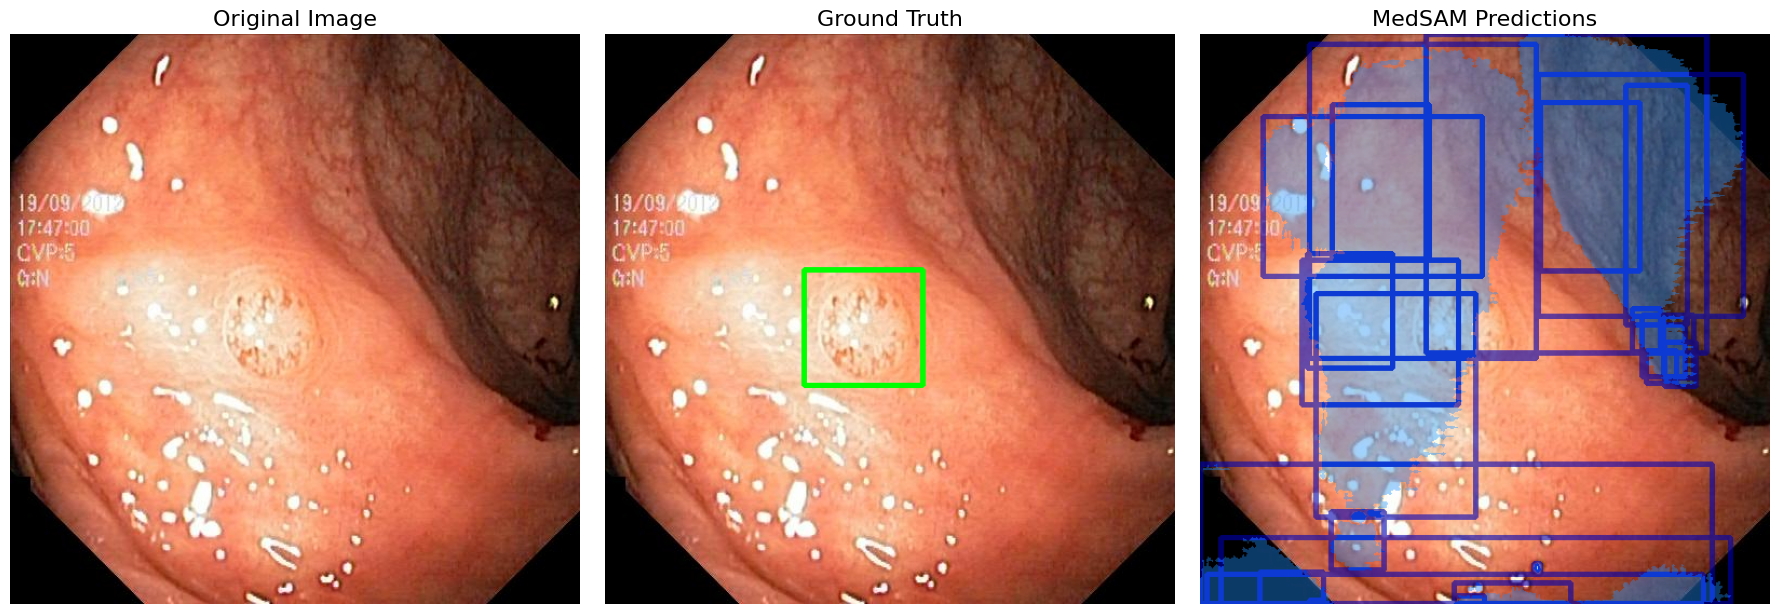


Ground Truth Boxes:
[[184, 218, 294, 325]]

Prediction Boxes:
[[313, 37, 503, 261], [315, 63, 407, 219], [235, 508, 343, 527], [209, 0, 469, 295], [409, 260, 449, 317], [309, 490, 315, 498], [94, 209, 239, 343], [101, 9, 311, 300], [122, 65, 212, 208], [99, 203, 178, 309], [6, 500, 466, 527], [394, 47, 451, 269], [413, 293, 441, 323], [430, 285, 459, 326], [235, 520, 263, 527], [429, 260, 457, 318], [58, 76, 261, 224], [121, 442, 170, 496], [101, 524, 114, 527], [19, 466, 491, 527], [0, 398, 474, 527], [55, 498, 114, 527], [400, 254, 426, 294], [107, 240, 255, 447]]


In [49]:
# =========================================================
# MEDSAM VISUALIZATION
# Original Image + Ground Truth + Predicted Masks + Boxes
# =========================================================

import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

from segment_anything import (
    sam_model_registry,
    SamAutomaticMaskGenerator
)

# =========================================================
# CONFIG
# =========================================================
IMAGE_PATH = r"C:\Medical_image_analysis\yolov8_kvasir\images\train\cju2rzpsmtb0f0835jabkbao1.jpg"

GT_PATH = r"C:\Medical_image_analysis\yolov8_kvasir\labels\train\cju2rzpsmtb0f0835jabkbao1.txt"

CHECKPOINT = r"C:\Users\Admin\MedSAM_Project\medsam_vit_b.pth"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# =========================================================
# RELAXED PARAMETERS FOR VISUALIZATION
# =========================================================
POINTS_PER_SIDE = 32

PRED_IOU_THRESH = 0.2

STABILITY_SCORE_THRESH = 0.5

MIN_MASK_AREA = 50

CONF_THRESH = 0.1

NMS_IOU_THRESH = 0.5

MAX_DETECTIONS = 100

# =========================================================
# AREA FILTER
# =========================================================
MIN_POLYP_AREA_RATIO = 0.0001

MAX_POLYP_AREA_RATIO = 0.8

# =========================================================
# LOAD MEDSAM
# =========================================================
print("Loading MedSAM...")

sam = sam_model_registry["vit_b"](
    checkpoint=CHECKPOINT
)

sam.to(DEVICE)

sam.eval()

# =========================================================
# MASK GENERATOR
# =========================================================
mask_generator = SamAutomaticMaskGenerator(
    model=sam,
    points_per_side=POINTS_PER_SIDE,
    pred_iou_thresh=PRED_IOU_THRESH,
    stability_score_thresh=STABILITY_SCORE_THRESH,
    min_mask_region_area=MIN_MASK_AREA,
)

# =========================================================
# IOU FUNCTION
# =========================================================
def compute_iou(boxA, boxB):

    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])

    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    inter = max(0, xB - xA) * max(0, yB - yA)

    areaA = (
        (boxA[2] - boxA[0]) *
        (boxA[3] - boxA[1])
    )

    areaB = (
        (boxB[2] - boxB[0]) *
        (boxB[3] - boxB[1])
    )

    union = areaA + areaB - inter

    return inter / union if union > 0 else 0

# =========================================================
# MASK TO BOX
# =========================================================
def mask_to_box(mask):

    y, x = np.where(mask)

    if len(x) == 0:
        return None

    return [
        int(x.min()),
        int(y.min()),
        int(x.max()),
        int(y.max())
    ]

# =========================================================
# AREA FILTER
# =========================================================
def is_valid_polyp_box(box, h, w):

    area = (
        (box[2] - box[0]) *
        (box[3] - box[1])
    )

    img_area = h * w

    ratio = area / img_area

    return (
        MIN_POLYP_AREA_RATIO <
        ratio <
        MAX_POLYP_AREA_RATIO
    )

# =========================================================
# APPLY NMS
# =========================================================
def apply_nms(masks):

    if len(masks) == 0:
        return []

    masks = sorted(
        masks,
        key=lambda x: x.get(
            'stability_score',
            x['predicted_iou']
        ),
        reverse=True
    )

    keep = []

    keep_boxes = []

    for m in masks:

        box = mask_to_box(
            m['segmentation']
        )

        if box is None:
            continue

        valid = True

        for kb in keep_boxes:

            if compute_iou(box, kb) > NMS_IOU_THRESH:

                valid = False
                break

        if valid:

            keep.append(m)

            keep_boxes.append(box)

    return keep

# =========================================================
# LOAD GROUND TRUTH
# =========================================================
def load_gt(path, w, h):

    boxes = []

    with open(path) as f:

        for line in f:

            _, cx, cy, bw, bh = map(
                float,
                line.strip().split()
            )

            x1 = int((cx - bw/2) * w)
            y1 = int((cy - bh/2) * h)

            x2 = int((cx + bw/2) * w)
            y2 = int((cy + bh/2) * h)

            boxes.append([x1, y1, x2, y2])

    return boxes

# =========================================================
# LOAD IMAGE
# =========================================================
img_bgr = cv2.imread(IMAGE_PATH)

if img_bgr is None:
    raise ValueError("Image not found!")

img_rgb = cv2.cvtColor(
    img_bgr,
    cv2.COLOR_BGR2RGB
)

h, w = img_rgb.shape[:2]

# =========================================================
# LOAD GT
# =========================================================
gt_boxes = load_gt(GT_PATH, w, h)

# =========================================================
# GENERATE MASKS
# =========================================================
print("Generating masks...")

masks = mask_generator.generate(img_rgb)

print(f"Total raw masks: {len(masks)}")

# =========================================================
# CONFIDENCE FILTER
# =========================================================
filtered_masks = []

for m in masks:

    if m.get('predicted_iou', 0) > CONF_THRESH:

        filtered_masks.append(m)

print(f"After confidence filtering: {len(filtered_masks)}")

# =========================================================
# APPLY NMS
# =========================================================
filtered_masks = apply_nms(filtered_masks)

print(f"After NMS: {len(filtered_masks)}")

filtered_masks = filtered_masks[:MAX_DETECTIONS]

# =========================================================
# VISUALIZATION IMAGES
# =========================================================
original = img_rgb.copy()

gt_img = img_rgb.copy()

pred_img = img_rgb.copy()

# =========================================================
# DRAW GT BOXES (GREEN)
# =========================================================
for gt in gt_boxes:

    cv2.rectangle(
        gt_img,
        (gt[0], gt[1]),
        (gt[2], gt[3]),
        (0, 255, 0),
        3
    )

# =========================================================
# CREATE OVERLAY
# =========================================================
overlay = pred_img.copy()

# =========================================================
# DRAW PREDICTED MASKS + BOXES
# =========================================================
pred_boxes = []

for m in filtered_masks:

    mask = m["segmentation"]

    box = mask_to_box(mask)

    if (
        box and
        is_valid_polyp_box(box, h, w)
    ):

        # ---------------------------------------
        # BLUE SHADED SEGMENTATION MASK
        # ---------------------------------------
        overlay[mask] = (30, 144, 255)

        # ---------------------------------------
        # DARK BLUE BOUNDING BOX
        # ---------------------------------------
        cv2.rectangle(
            pred_img,
            (box[0], box[1]),
            (box[2], box[3]),
            (0, 0, 180),
            3
        )

        pred_boxes.append(box)

# =========================================================
# APPLY TRANSPARENCY
# =========================================================
alpha = 0.4

pred_img = cv2.addWeighted(
    overlay,
    alpha,
    pred_img,
    1 - alpha,
    0
)

# =========================================================
# VISUALIZATION
# =========================================================
plt.figure(figsize=(18,6))

# ORIGINAL IMAGE
plt.subplot(1,3,1)

plt.imshow(original)

plt.title("Original Image", fontsize=16)

plt.axis("off")

# GROUND TRUTH
plt.subplot(1,3,2)

plt.imshow(gt_img)

plt.title("Ground Truth", fontsize=16)

plt.axis("off")

# MEDSAM PREDICTIONS
plt.subplot(1,3,3)

plt.imshow(pred_img)

plt.title("MedSAM Predictions", fontsize=16)

plt.axis("off")

plt.tight_layout()

plt.show()

# =========================================================
# PRINT RESULTS
# =========================================================
print("\nGround Truth Boxes:")
print(gt_boxes)

print("\nPrediction Boxes:")
print(pred_boxes)

Loading DINOv2...


Loading weights: 100%|██████████| 223/223 [00:00<00:00, 5119.37it/s]



Building reference features...
Using 6 reference patches

Extracting patch features...

Computing similarity map...


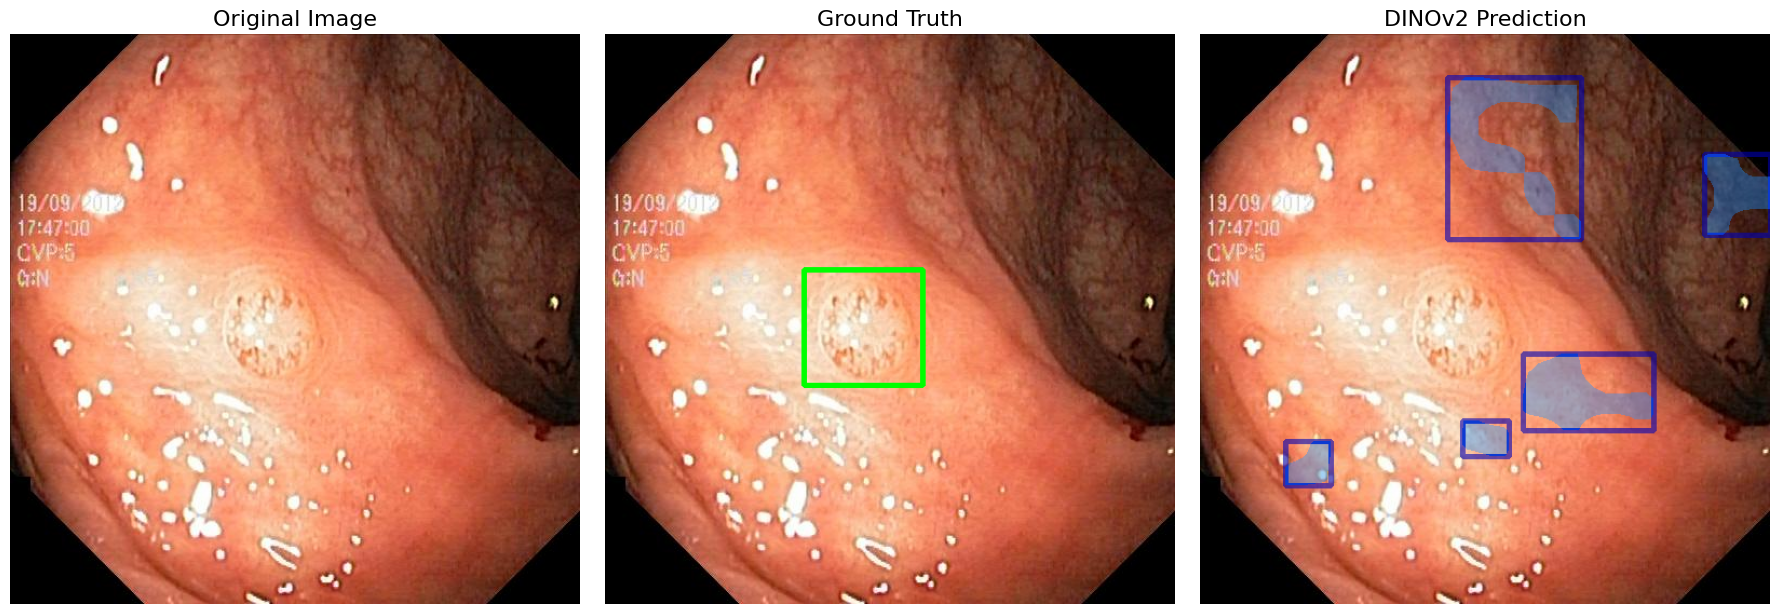


Visualization complete!


In [50]:
# =========================================================
# CLEAN DINOv2 POLYP LOCALIZATION VISUALIZATION
# BLUE MASK + DARK BLUE BOUNDING BOX
# =========================================================

import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from transformers import AutoImageProcessor, AutoModel

# =========================================================
# CONFIG
# =========================================================
IMAGE_PATH = r"C:\Medical_image_analysis\yolov8_kvasir\images\train\cju2rzpsmtb0f0835jabkbao1.jpg"

GT_PATH = r"C:\Medical_image_analysis\yolov8_kvasir\labels\train\cju2rzpsmtb0f0835jabkbao1.txt"

REFERENCE_PATCH_DIR = r"C:\Users\Admin\MedSAM_Project\reference_patches"

MODEL_NAME = "facebook/dinov2-base"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# =========================================================
# LOAD DINOv2
# =========================================================
print("Loading DINOv2...")

processor = AutoImageProcessor.from_pretrained(
    MODEL_NAME
)

model = AutoModel.from_pretrained(
    MODEL_NAME
)

model.to(DEVICE)

model.eval()

# =========================================================
# BUILD REFERENCE FEATURE
# =========================================================
def build_reference():

    files = [

        f for f in os.listdir(
            REFERENCE_PATCH_DIR
        )

        if f.lower().endswith(
            (".png", ".jpg", ".jpeg")
        )
    ]

    if len(files) == 0:

        raise ValueError(
            "No reference patches found!"
        )

    print(
        f"Using {len(files)} reference patches"
    )

    feats = []

    for f in files:

        path = os.path.join(
            REFERENCE_PATCH_DIR,
            f
        )

        img = Image.open(path).convert("RGB")

        inputs = processor(
            images=img,
            return_tensors="pt"
        )

        pixel_values = inputs[
            "pixel_values"
        ].to(DEVICE)

        with torch.no_grad():

            outputs = model(pixel_values)

            patch_tokens = (
                outputs
                .last_hidden_state
                .squeeze(0)[1:]
            )

            feat = (
                patch_tokens
                .mean(dim=0)
                .cpu()
                .numpy()
            )

        feats.append(feat)

    ref = np.mean(
        np.stack(feats),
        axis=0
    )

    ref = ref / (
        np.linalg.norm(ref) + 1e-8
    )

    return ref

# =========================================================
# EXTRACT PATCH FEATURES
# =========================================================
def get_patch_features(img_path):

    img = Image.open(img_path).convert("RGB")

    inputs = processor(
        images=img,
        return_tensors="pt"
    )

    pixel_values = inputs[
        "pixel_values"
    ].to(DEVICE)

    with torch.no_grad():

        outputs = model(pixel_values)

        patch_feats = (
            outputs
            .last_hidden_state
            .squeeze(0)[1:]
        )

    img_np = np.array(img)

    H, W = pixel_values.shape[-2:]

    patch_size = model.config.patch_size

    grid_h = H // patch_size

    grid_w = W // patch_size

    actual_patches = patch_feats.shape[0]

    expected = grid_h * grid_w

    if expected != actual_patches:

        grid_h = int(
            np.sqrt(actual_patches)
        )

        grid_w = (
            actual_patches // grid_h
        )

    return (
        patch_feats,
        img_np,
        grid_h,
        grid_w
    )

# =========================================================
# COSINE SIMILARITY
# =========================================================
def compute_similarity(
    patch_feats,
    ref
):

    patch_feats = (
        patch_feats
        .cpu()
        .numpy()
    )

    patch_feats = patch_feats / (

        np.linalg.norm(
            patch_feats,
            axis=1,
            keepdims=True
        ) + 1e-8
    )

    sim = np.dot(
        patch_feats,
        ref
    )

    return sim

# =========================================================
# LOAD GT
# =========================================================
def load_gt(path, w, h):

    boxes = []

    with open(path) as f:

        for line in f:

            _, cx, cy, bw, bh = map(
                float,
                line.strip().split()
            )

            x1 = int(
                (cx - bw/2) * w
            )

            y1 = int(
                (cy - bh/2) * h
            )

            x2 = int(
                (cx + bw/2) * w
            )

            y2 = int(
                (cy + bh/2) * h
            )

            boxes.append([
                x1,
                y1,
                x2,
                y2
            ])

    return boxes

# =========================================================
# MAIN
# =========================================================
print(
    "\nBuilding reference features..."
)

ref = build_reference()

print(
    "\nExtracting patch features..."
)

(
    patch_feats,
    img_np,
    grid_h,
    grid_w

) = get_patch_features(
    IMAGE_PATH
)

h, w = img_np.shape[:2]

print(
    "\nComputing similarity map..."
)

similarities = compute_similarity(
    patch_feats,
    ref
)

# =========================================================
# SIMILARITY MAP
# =========================================================
sim_map = similarities.reshape(
    grid_h,
    grid_w
)

sim_map = cv2.resize(
    sim_map,
    (w, h)
)

# =========================================================
# NORMALIZE
# =========================================================
sim_norm = cv2.normalize(
    sim_map,
    None,
    0,
    255,
    cv2.NORM_MINMAX
).astype(np.uint8)

# =========================================================
# THRESHOLD
# =========================================================
threshold = np.percentile(
    sim_norm,
    92
)

binary_mask = (
    sim_norm > threshold
).astype(np.uint8)

# =========================================================
# MORPHOLOGICAL CLEANING
# =========================================================
kernel = np.ones((15,15), np.uint8)

binary_mask = cv2.morphologyEx(
    binary_mask,
    cv2.MORPH_OPEN,
    kernel
)

binary_mask = cv2.morphologyEx(
    binary_mask,
    cv2.MORPH_CLOSE,
    kernel
)

# =========================================================
# FIND CONTOURS
# =========================================================
contours, _ = cv2.findContours(
    binary_mask,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

# =========================================================
# LOAD GT
# =========================================================
gt_boxes = load_gt(
    GT_PATH,
    w,
    h
)

# =========================================================
# VISUALIZATION IMAGES
# =========================================================
original = img_np.copy()

gt_img = img_np.copy()

dino_img = img_np.copy()

overlay = img_np.copy()

# =========================================================
# DRAW GT BOXES
# =========================================================
for gt in gt_boxes:

    cv2.rectangle(
        gt_img,
        (gt[0], gt[1]),
        (gt[2], gt[3]),
        (0,255,0),
        3
    )

# =========================================================
# DRAW DINOv2 MASK + BOX
# =========================================================
for cnt in contours:

    area = cv2.contourArea(cnt)

    # remove tiny noisy regions
    if area < 1000:
        continue

    x, y, bw, bh = cv2.boundingRect(cnt)

    # ------------------------------------------
    # CREATE CONTOUR MASK
    # ------------------------------------------
    mask = np.zeros(
        (h, w),
        dtype=np.uint8
    )

    cv2.drawContours(
        mask,
        [cnt],
        -1,
        255,
        thickness=-1
    )

    # ------------------------------------------
    # BLUE SHADED REGION
    # ------------------------------------------
    overlay[mask > 0] = (
        30,
        144,
        255
    )

    # ------------------------------------------
    # DARK BLUE BOUNDING BOX
    # ------------------------------------------
    cv2.rectangle(
        dino_img,
        (x, y),
        (x+bw, y+bh),
        (0, 0, 180),
        3
    )

# =========================================================
# APPLY TRANSPARENCY
# =========================================================
alpha = 0.4

dino_img = cv2.addWeighted(
    overlay,
    alpha,
    dino_img,
    1 - alpha,
    0
)

# =========================================================
# VISUALIZATION
# =========================================================
plt.figure(figsize=(18,6))

# ORIGINAL
plt.subplot(1,3,1)

plt.imshow(original)

plt.title(
    "Original Image",
    fontsize=16
)

plt.axis("off")

# GT
plt.subplot(1,3,2)

plt.imshow(gt_img)

plt.title(
    "Ground Truth",
    fontsize=16
)

plt.axis("off")

# DINOv2
plt.subplot(1,3,3)

plt.imshow(dino_img)

plt.title(
    "DINOv2 Prediction",
    fontsize=16
)

plt.axis("off")

plt.tight_layout()

plt.show()

print("\nVisualization complete!")

Loading YOLOv8 model...
Running YOLOv8 inference...
Detected boxes: 1


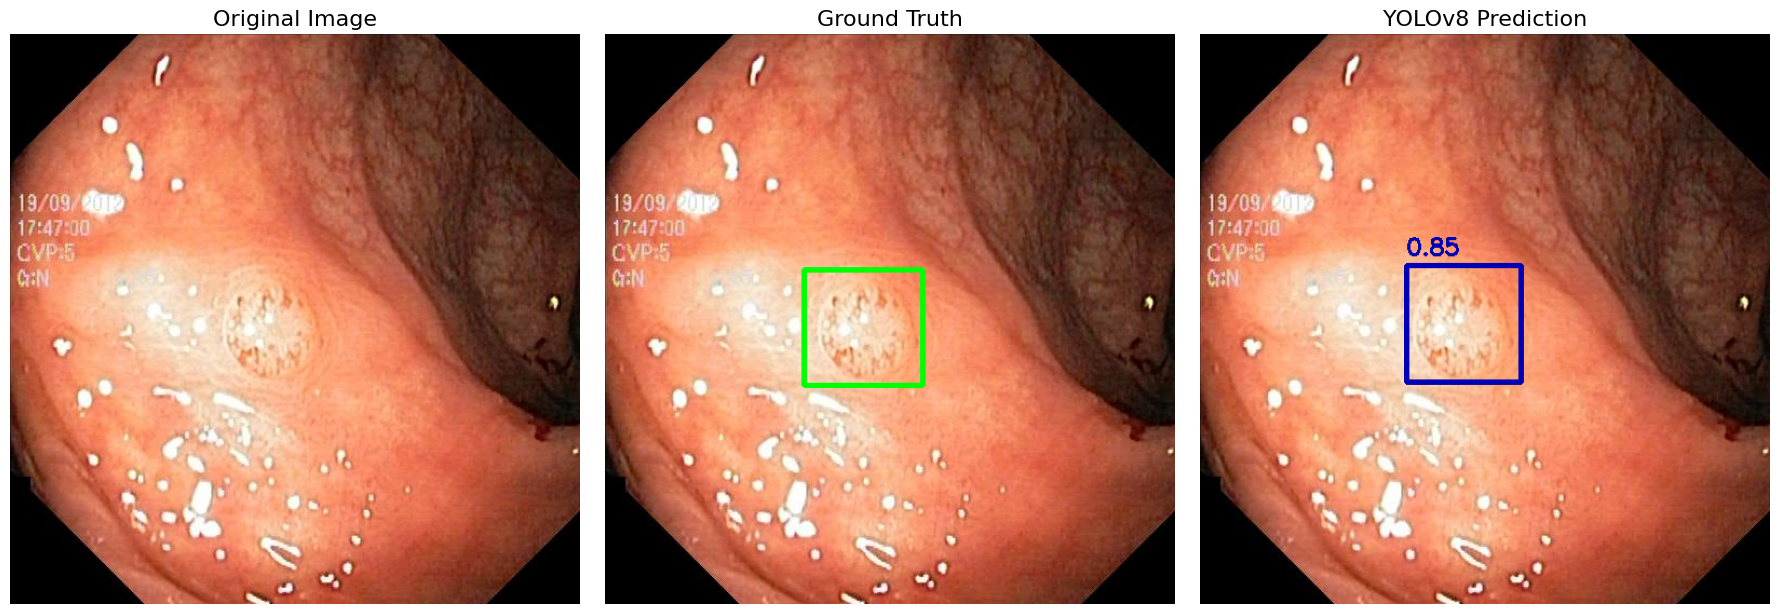


Ground Truth Boxes:
[[184, 218, 294, 325]]

Predicted Boxes:
[{'box': [191, 214, 297, 322], 'conf': 0.8539801836013794}]


In [51]:
# =========================================================
# YOLOv8 POLYP DETECTION VISUALIZATION
# ONLY DARK BLUE BOUNDING BOXES
# =========================================================

import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

from ultralytics import YOLO

# =========================================================
# CONFIG
# =========================================================
IMAGE_PATH = r"C:\Medical_image_analysis\yolov8_kvasir\images\train\cju2rzpsmtb0f0835jabkbao1.jpg"

GT_PATH = r"C:\Medical_image_analysis\yolov8_kvasir\labels\train\cju2rzpsmtb0f0835jabkbao1.txt"

MODEL_PATH = r"C:\Medical_image_analysis\yolov8_kvasir\results\YOLOv8\kvasir-seg_augmentation_10_percent_negative_yolov8\yolov8l_kvasir_train_25_06\weights\best.pt"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

CONF_THRESH = 0.25

# =========================================================
# LOAD YOLOv8 MODEL
# =========================================================
print("Loading YOLOv8 model...")

model = YOLO(MODEL_PATH)

# =========================================================
# LOAD IMAGE
# =========================================================
img_bgr = cv2.imread(IMAGE_PATH)

if img_bgr is None:
    raise ValueError("Image not found!")

img_rgb = cv2.cvtColor(
    img_bgr,
    cv2.COLOR_BGR2RGB
)

h, w = img_rgb.shape[:2]

# =========================================================
# LOAD GT BOXES
# =========================================================
def load_gt(path, w, h):

    boxes = []

    with open(path) as f:

        for line in f:

            _, cx, cy, bw, bh = map(
                float,
                line.strip().split()
            )

            x1 = int((cx - bw/2) * w)

            y1 = int((cy - bh/2) * h)

            x2 = int((cx + bw/2) * w)

            y2 = int((cy + bh/2) * h)

            boxes.append([
                x1,
                y1,
                x2,
                y2
            ])

    return boxes

gt_boxes = load_gt(
    GT_PATH,
    w,
    h
)

# =========================================================
# YOLOv8 INFERENCE
# =========================================================
print("Running YOLOv8 inference...")

results = model.predict(
    source=IMAGE_PATH,
    conf=CONF_THRESH,
    device=0 if DEVICE == "cuda" else "cpu",
    verbose=False
)

# =========================================================
# EXTRACT PREDICTIONS
# =========================================================
pred_boxes = []

for r in results:

    if r.boxes is None:
        continue

    boxes = r.boxes.xyxy.cpu().numpy()

    confs = r.boxes.conf.cpu().numpy()

    for box, conf in zip(boxes, confs):

        x1, y1, x2, y2 = map(int, box)

        pred_boxes.append({

            "box": [x1, y1, x2, y2],

            "conf": float(conf)

        })

print(f"Detected boxes: {len(pred_boxes)}")

# =========================================================
# VISUALIZATION IMAGES
# =========================================================
original = img_rgb.copy()

gt_img = img_rgb.copy()

pred_img = img_rgb.copy()

# =========================================================
# DRAW GT BOXES (GREEN)
# =========================================================
for gt in gt_boxes:

    cv2.rectangle(
        gt_img,
        (gt[0], gt[1]),
        (gt[2], gt[3]),
        (0,255,0),
        3
    )

# =========================================================
# DRAW YOLO PREDICTIONS (DARK BLUE)
# =========================================================
for p in pred_boxes:

    box = p["box"]

    conf = p["conf"]

    x1, y1, x2, y2 = box

    # -----------------------------------------------------
    # DARK BLUE BOUNDING BOX
    # -----------------------------------------------------
    cv2.rectangle(
        pred_img,
        (x1, y1),
        (x2, y2),
        (0, 0, 180),
        3
    )

    # -----------------------------------------------------
    # CONFIDENCE TEXT
    # -----------------------------------------------------
    cv2.putText(
        pred_img,
        f"{conf:.2f}",
        (x1, y1 - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (0, 0, 180),
        2
    )

# =========================================================
# VISUALIZATION
# =========================================================
plt.figure(figsize=(18,6))

# ORIGINAL IMAGE
plt.subplot(1,3,1)

plt.imshow(original)

plt.title(
    "Original Image",
    fontsize=16
)

plt.axis("off")

# GROUND TRUTH
plt.subplot(1,3,2)

plt.imshow(gt_img)

plt.title(
    "Ground Truth",
    fontsize=16
)

plt.axis("off")

# YOLOv8 PREDICTION
plt.subplot(1,3,3)

plt.imshow(pred_img)

plt.title(
    "YOLOv8 Prediction",
    fontsize=16
)

plt.axis("off")

plt.tight_layout()

plt.show()

# =========================================================
# PRINT RESULTS
# =========================================================
print("\nGround Truth Boxes:")
print(gt_boxes)

print("\nPredicted Boxes:")
print(pred_boxes)

Loading YOLOv12 model...
Running YOLOv12 inference...
Detected boxes: 1


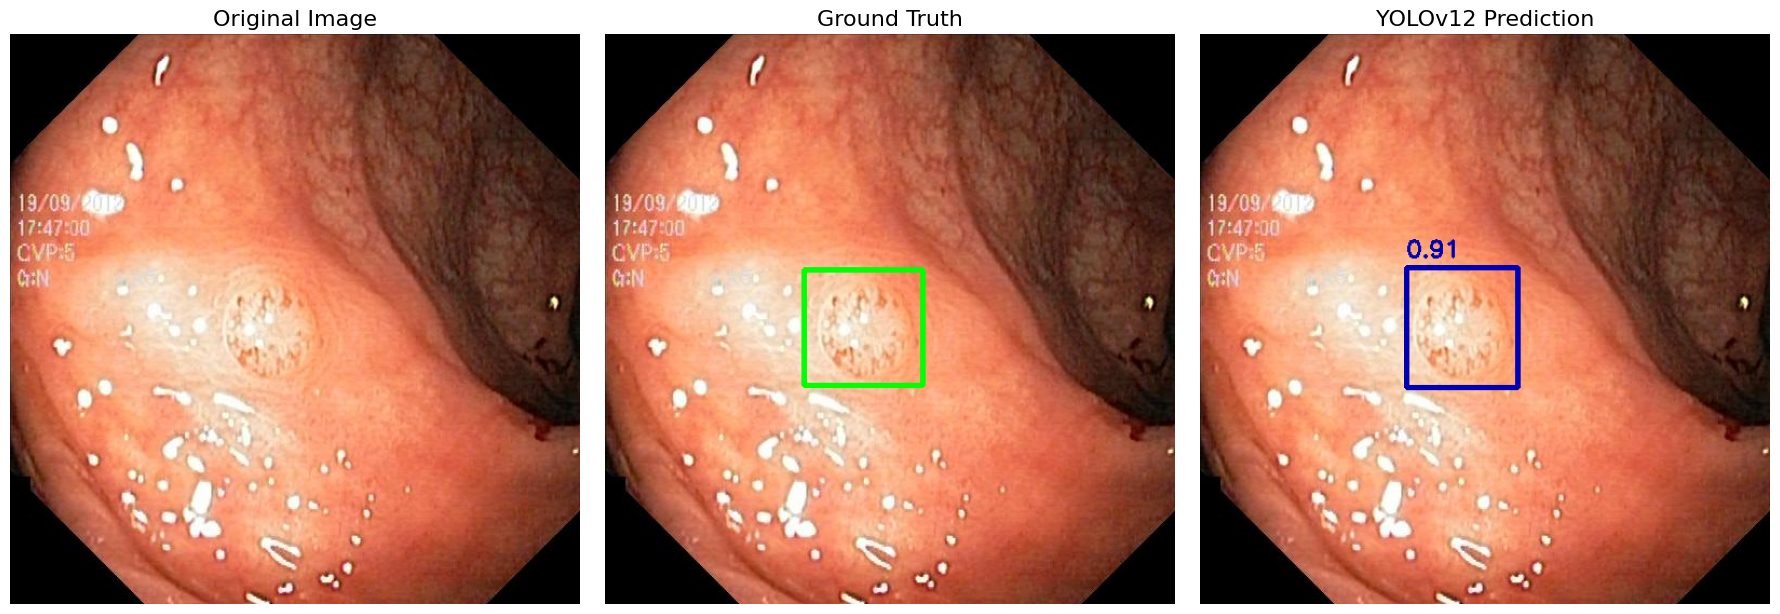


Ground Truth Boxes:
[[184, 218, 294, 325]]

Predicted Boxes:
[{'box': [191, 216, 294, 327], 'conf': 0.9106848835945129}]


In [52]:
# =========================================================
# YOLOv12 POLYP DETECTION VISUALIZATION
# ONLY DARK BLUE BOUNDING BOXES
# =========================================================

import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

from ultralytics import YOLO

# =========================================================
# CONFIG
# =========================================================
IMAGE_PATH = r"C:\Medical_image_analysis\yolov8_kvasir\images\train\cju2rzpsmtb0f0835jabkbao1.jpg"

GT_PATH = r"C:\Medical_image_analysis\yolov8_kvasir\labels\train\cju2rzpsmtb0f0835jabkbao1.txt"

MODEL_PATH = r"C:\Medical_image_analysis\yolov8_kvasir\results\YOLOv12\YOLOv12_kvasir-seg_dataset_with_augmentations_10_negative\yolov12_l_kvasir_with_augmen_10_negative3\weights\best.pt"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

CONF_THRESH = 0.25

# =========================================================
# LOAD YOLOv12 MODEL
# =========================================================
print("Loading YOLOv12 model...")

model = YOLO(MODEL_PATH)

# =========================================================
# LOAD IMAGE
# =========================================================
img_bgr = cv2.imread(IMAGE_PATH)

if img_bgr is None:
    raise ValueError("Image not found!")

img_rgb = cv2.cvtColor(
    img_bgr,
    cv2.COLOR_BGR2RGB
)

h, w = img_rgb.shape[:2]

# =========================================================
# LOAD GT BOXES
# =========================================================
def load_gt(path, w, h):

    boxes = []

    with open(path) as f:

        for line in f:

            _, cx, cy, bw, bh = map(
                float,
                line.strip().split()
            )

            x1 = int((cx - bw/2) * w)

            y1 = int((cy - bh/2) * h)

            x2 = int((cx + bw/2) * w)

            y2 = int((cy + bh/2) * h)

            boxes.append([
                x1,
                y1,
                x2,
                y2
            ])

    return boxes

gt_boxes = load_gt(
    GT_PATH,
    w,
    h
)

# =========================================================
# YOLOv12 INFERENCE
# =========================================================
print("Running YOLOv12 inference...")

results = model.predict(
    source=IMAGE_PATH,
    conf=CONF_THRESH,
    device=0 if DEVICE == "cuda" else "cpu",
    verbose=False
)

# =========================================================
# EXTRACT PREDICTIONS
# =========================================================
pred_boxes = []

for r in results:

    if r.boxes is None:
        continue

    boxes = r.boxes.xyxy.cpu().numpy()

    confs = r.boxes.conf.cpu().numpy()

    for box, conf in zip(boxes, confs):

        x1, y1, x2, y2 = map(int, box)

        pred_boxes.append({

            "box": [x1, y1, x2, y2],

            "conf": float(conf)

        })

print(f"Detected boxes: {len(pred_boxes)}")

# =========================================================
# VISUALIZATION IMAGES
# =========================================================
original = img_rgb.copy()

gt_img = img_rgb.copy()

pred_img = img_rgb.copy()

# =========================================================
# DRAW GT BOXES (GREEN)
# =========================================================
for gt in gt_boxes:

    cv2.rectangle(
        gt_img,
        (gt[0], gt[1]),
        (gt[2], gt[3]),
        (0,255,0),
        3
    )

# =========================================================
# DRAW YOLOv12 PREDICTIONS (DARK BLUE)
# =========================================================
for p in pred_boxes:

    box = p["box"]

    conf = p["conf"]

    x1, y1, x2, y2 = box

    # -----------------------------------------------------
    # DARK BLUE BOUNDING BOX
    # -----------------------------------------------------
    cv2.rectangle(
        pred_img,
        (x1, y1),
        (x2, y2),
        (0, 0, 180),
        3
    )

    # -----------------------------------------------------
    # CONFIDENCE TEXT
    # -----------------------------------------------------
    cv2.putText(
        pred_img,
        f"{conf:.2f}",
        (x1, y1 - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (0, 0, 180),
        2
    )

# =========================================================
# VISUALIZATION
# =========================================================
plt.figure(figsize=(18,6))

# ORIGINAL IMAGE
plt.subplot(1,3,1)

plt.imshow(original)

plt.title(
    "Original Image",
    fontsize=16
)

plt.axis("off")

# GROUND TRUTH
plt.subplot(1,3,2)

plt.imshow(gt_img)

plt.title(
    "Ground Truth",
    fontsize=16
)

plt.axis("off")

# YOLOv12 PREDICTION
plt.subplot(1,3,3)

plt.imshow(pred_img)

plt.title(
    "YOLOv12 Prediction",
    fontsize=16
)

plt.axis("off")

plt.tight_layout()

plt.show()

# =========================================================
# PRINT RESULTS
# =========================================================
print("\nGround Truth Boxes:")
print(gt_boxes)

print("\nPredicted Boxes:")
print(pred_boxes)